<a href="https://colab.research.google.com/github/hmezer/fog-of-crisis-exec-comms/blob/main/fog-of-crisis-exec-comms-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## INITIAL SETUP

In [ ]:
# Download the clean requirements file from your GitHub
!wget -O requirements.txt "https://raw.githubusercontent.com/hmezer/fog-of-crisis-exec-comms/main/requirements.txt"

# Install exactly what is needed
!pip install -r requirements.txt

--2026-04-01 18:41:45--  https://raw.githubusercontent.com/hmezer/fog-of-crisis-exec-comms/main/requirements.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149 [text/plain]
Saving to: ‘requirements.txt’

requirements.txt    100%[===================>]     149  --.-KB/s    in 0s      

2026-04-01 18:41:45 (10.7 MB/s) - ‘requirements.txt’ saved [149/149]



In [ ]:
import pandas as pd

url = "https://github.com/hmezer/fog-of-crisis-exec-comms/releases/download/dataset/youtube_data_anonymized.parquet"
data_org = pd.read_parquet(url)

---
---

## PREPROCESSING AND DATA MERGE

Plot saved to 'data_validity_check.png'


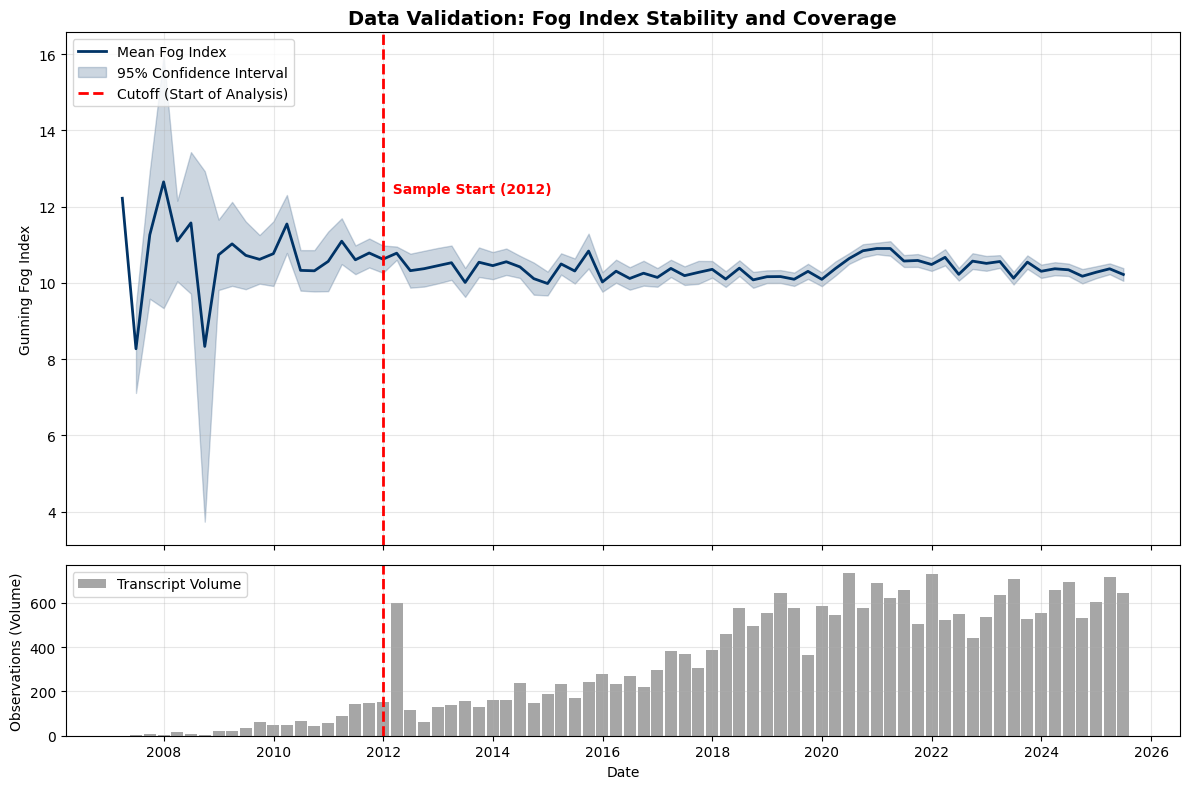

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Prep Data
# ---------------------------------------------------------
df = data_org.copy()
df['publish_date'] = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)

df = df.set_index('publish_date').sort_index()

# 2. Aggregation (Quarterly)
# ---------------------------------------------------------
# We calculate Mean, Count, and Standard Error for CI
q_stats = df['fog_index'].resample('QE').agg(['mean', 'count', 'std', 'sem'])

# Calculate 95% Confidence Intervals
q_stats['ci95_hi'] = q_stats['mean'] + 1.96 * q_stats['sem']
q_stats['ci95_lo'] = q_stats['mean'] - 1.96 * q_stats['sem']

# 3. Visualization
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# --- Top Plot: Fog Index & CI ---
ax1.plot(q_stats.index, q_stats['mean'], color='#003366', linewidth=2, label='Mean Fog Index')
ax1.fill_between(q_stats.index, q_stats['ci95_lo'], q_stats['ci95_hi'],
                 color='#003366', alpha=0.2, label='95% Confidence Interval')

# Mark the Cutoff
cutoff_date = pd.Timestamp('2012-01-01')
ax1.axvline(cutoff_date, color='red', linestyle='--', linewidth=2, label='Cutoff (Start of Analysis)')
ax1.text(cutoff_date, q_stats['mean'].max(), '  Sample Start (2012)', color='red',
         verticalalignment='top', fontweight='bold')

# Styling
ax1.set_title('Data Validation: Fog Index Stability and Coverage', fontsize=14, fontweight='bold')
ax1.set_ylabel('Gunning Fog Index')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Bottom Plot: Volume ---
# Width corresponds to ~90 days (1 quarter)
ax2.bar(q_stats.index, q_stats['count'], width=80, color='gray', alpha=0.7, label='Transcript Volume')

ax2.set_ylabel('Observations (Volume)')
ax2.set_xlabel('Date')
ax2.axvline(cutoff_date, color='red', linestyle='--', linewidth=2)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.savefig('data_validity_check.png', dpi=300)
print("Plot saved to 'data_validity_check.png'")
plt.show()

We restrict our sample to the post-2012 period to ensure statistical robustness. Prior to 2012, the dataset exhibits **volume scarcity** (low number of observations) and **high variance**, which introduce noise into the baseline trend. By setting the cutoff at 2012, we guarantee that our 'Business as Usual' reference period (2012–2019) is constructed on a stable, high-density sample, preventing artifacts of data collection from masquerading as economic signals.

---

### **Extracting Market Data from `yfinance` API**

This script implements a **"Dual-Frequency" feature engineering pipeline**, designed to prepare financial time-series data for machine learning. It merges high-frequency daily signals with low-frequency quarterly trends while strictly preventing data leakage.

#### **1. The "Hybrid" Architecture**
* **Method:** The script calculates features on two distinct time horizons:
    * **Micro-Level (Daily):** 7-day/30-day rolling windows.
    * **Macro-Level (Quarterly):** Aggregated quarterly volatility and returns.
* **The Why:** Financial markets are driven by both immediate news (micro) and structural regimes (macro). A model trained only on daily data misses the broader context (e.g., "Is this high volatility normal for this quarter?").

#### **2. Prevention of Look-Ahead Bias (The `ffill` Logic)**
* **Method:** It calculates quarterly statistics using `resample('Q')`, but then re-aligns them to daily data using `reindex(..., method='ffill')` and adds a `Prev_` prefix.
* **The Why:** You cannot use Q1 statistics to predict Q1 prices because Q1 isn't finished yet. By forward-filling, the script projects **Q1's finished stats onto every day of Q2**. This ensures the model only sees data that would have actually been available at that moment in time.

#### **3. Stationarity & Normalization**
* **Method:** Instead of raw prices (`Close`) or raw volume, the script computes **Percentage Changes** (`pct_change`) and **Abnormal Volume Ratios** (`Volume / 30d_Avg`).
* **The Why:** Raw prices are "non-stationary" (unbounded). A stock at $2,000 behaves differently than at $10 mathematically. Converting to returns and ratios normalizes the data, allowing the ML model to learn universal patterns rather than memorizing specific price levels.

The below market data extraction takes ~10 minutes.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# Configuration
df_main = data_org.copy()

# For testing purposes (Comment out the line above and uncomment below to test)
#tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'JPM'] * 20
tickers = df_main['ticker'].unique().tolist()

start_date = "2011-06-01"
end_date = "2025-07-01"

def get_hybrid_market_data(ticker_list):
    all_data = []
    total_tickers = len(ticker_list)
    print(f"Starting extraction for {total_tickers} companies...")

    # Use enumerate to track the index 'i' (starting from 0)
    for i, ticker in enumerate(ticker_list):
        try:
            clean_ticker = str(ticker).strip().upper()

            # 1. Download Daily Data
            df_daily = yf.download(clean_ticker, start=start_date, end=end_date, progress=False, auto_adjust=False)

            if df_daily.empty:
                print(f"Skipping {clean_ticker}: No data found.")
                # Even if skipped, we count it as "scanned" for the progress bar
            else:
                # 2. FLATTEN MULTI-INDEX
                if isinstance(df_daily.columns, pd.MultiIndex):
                    df_daily.columns = df_daily.columns.get_level_values(0)

                # 3. Select Price & Volume
                price_col = 'Adj Close' if 'Adj Close' in df_daily.columns else 'Close'

                # Only proceed if we have the price column
                if price_col in df_daily.columns:
                    # Ensure 1D Series
                    price = df_daily[price_col]
                    volume = df_daily['Volume'] if 'Volume' in df_daily.columns else pd.Series(0, index=df_daily.index)

                    # ---------------------------------------------------------
                    # FEATURE SET A: "Recent Market Developments" (Rolling Windows)
                    # ---------------------------------------------------------
                    roll_ret_7d = price.pct_change(7)
                    roll_ret_30d = price.pct_change(30)

                    daily_ret = price.pct_change()
                    roll_vol_30d = daily_ret.rolling(window=30).std() * np.sqrt(252)

                    roll_vol_avg = volume.rolling(window=30).mean()
                    abnormal_vol = volume / roll_vol_avg

                    # ---------------------------------------------------------
                    # FEATURE SET B: "Quarterly Fundamentals" (Lagged Anchors)
                    # ---------------------------------------------------------
                    df_q = pd.DataFrame()
                    df_q['Q_Close'] = price.resample('QE').last()
                    df_q['Q_Return'] = df_q['Q_Close'].pct_change()
                    df_q['Q_Volatility'] = daily_ret.resample('QE').std() * np.sqrt(252)

                    # Reindex back to Daily (Forward Fill)
                    df_q_daily = df_q.reindex(df_daily.index, method='ffill')
                    df_q_daily = df_q_daily.add_prefix('Prev_')

                    # ---------------------------------------------------------
                    # COMBINE
                    # ---------------------------------------------------------
                    df_combined = pd.DataFrame({
                        'ticker': clean_ticker,
                        'price_close': price,

                        # Recent (Rolling)
                        'recent_ret_7d': roll_ret_7d,
                        'recent_ret_30d': roll_ret_30d,
                        'recent_vol_30d': roll_vol_30d,
                        'recent_abnormal_vol': abnormal_vol,

                        # Fundamental (Lagged Quarterly)
                        'prev_q_return': df_q_daily['Prev_Q_Return'],
                        'prev_q_volatility': df_q_daily['Prev_Q_Volatility']
                    })

                    all_data.append(df_combined)

        except Exception as e:
            print(f"Error processing {ticker}: {e}")

        # --- PROGRESS COUNTER ---
        scanned = i + 1
        if scanned % 50 == 0:
            left = total_tickers - scanned
            print(f"--> [Progress] Scanned: {scanned} | Left: {left}")

    if all_data:
        final_df = pd.concat(all_data)
        final_df.index.name = 'date'
        return final_df.reset_index()
    else:
        return pd.DataFrame()

# Execute
df_hybrid_market = get_hybrid_market_data(tickers)

# Drop initial NaNs (from rolling windows)
if not df_hybrid_market.empty:
    df_hybrid_market.dropna(subset=['recent_vol_30d'], inplace=True)
    print("\n--- Hybrid Extraction Complete ---")
    print(df_hybrid_market.head())

    # Save
    df_hybrid_market.to_csv("market_features_hybrid_daily.csv", index=False)
    print("Saved to 'market_features_hybrid_daily.csv'")
else:
    print("No data extracted.")

Starting extraction for 1065 companies...


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FL']: YFTzMissingError('possibly delisted; no timezone found')


Skipping FL: No data found.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['FLIR']: YFTzMissingError('possibly delisted; no timezone found')


Skipping FLIR: No data found.


...

Skipping SRCL: No data found.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['PETM']: YFPricesMissingError('possibly delisted; no price data found  (1d 2011-06-01 -> 2025-07-01)')


Skipping PETM: No data found.
--> [Progress] Scanned: 1050 | Left: 15


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TCF']: YFTzMissingError('possibly delisted; no timezone found')


Skipping TCF: No data found.

--- Hybrid Extraction Complete ---
         date ticker  price_close  recent_ret_7d  recent_ret_30d  \
30 2011-07-14   WAFD    11.504401       0.029770        0.105379   
31 2011-07-15   WAFD    11.592634       0.018486        0.103106   
32 2011-07-18   WAFD    11.565484       0.007688        0.122186   
33 2011-07-19   WAFD    11.633356       0.022063        0.146831   
34 2011-07-20   WAFD    11.626567       0.041970        0.147693   

    recent_vol_30d  recent_abnormal_vol  prev_q_return  prev_q_volatility  
30        0.236520             1.575522            NaN           0.243237  
31        0.236116             0.918634            NaN           0.243237  
32        0.226891             1.175298            NaN           0.243237  
33        0.219101             0.986696            NaN           0.243237  
34        0.218933             0.573806            NaN           0.243237  
Saved to 'market_features_hybrid_daily.csv'


We export the merged dataset containing the market data along with the original columns into a CSV file for later use.

In [ ]:
df_market_features = pd.read_csv("market_features_hybrid_daily.csv")
df_market_features_head = df_market_features.head(10)
df_market_features_head.to_csv("market_features_daily_head.csv", index=False)

Since there had been certain tickers for which there is no market data available (possibly because they are either absent or removed from the API), we will check how this affects the dataset.

In [ ]:
import pandas as pd

# 1. Load the Datasets
# ---------------------------------------------------------
# Assuming 'data_org' is your original loaded dataframe
df_interviews = data_org.copy()

# UPDATED: Load the new Hybrid Daily market data
df_market = pd.read_csv('market_features_hybrid_daily.csv')

# 2. Preprocessing & Standardization
# ---------------------------------------------------------
# A. Standardize Dates
df_interviews['publish_date'] = pd.to_datetime(df_interviews['publish_date'], utc=True).dt.tz_localize(None)
df_market['date'] = pd.to_datetime(df_market['date'], utc=True).dt.tz_localize(None)

# B. Standardize Tickers
df_interviews['ticker'] = df_interviews['ticker'].astype(str).str.strip().str.upper()
df_market['ticker'] = df_market['ticker'].astype(str).str.strip().str.upper()

# ---------------------------------------------------------
# 2.5. FILTERING
# ---------------------------------------------------------

# A. Drop rows with missing dates (Critical for logic)
print(f"Row Count (Raw): {len(df_interviews)}")
df_interviews = df_interviews.dropna(subset=['publish_date'])

# B. Filter 1: Time Period (Start from 2012)
df_interviews = df_interviews[df_interviews['publish_date'] >= '2012-01-01']
print(f"Row Count (2012+ Only): {len(df_interviews)}")

# C. Filter 2: Ticker Availability
valid_market_tickers = set(df_market['ticker'].unique())
df_interviews = df_interviews[df_interviews['ticker'].isin(valid_market_tickers)]
print(f"Row Count (Matched Tickers Only): {len(df_interviews)}")

# ---------------------------------------------------------

# C. Sort by Date (REQUIRED for merge_asof)
df_interviews = df_interviews.sort_values('publish_date')
df_market = df_market.sort_values('date')

# 3. The "Ultimate Merge" (Merge As-Of)
# ---------------------------------------------------------
# UPDATED LOGIC:
# We now have daily data, so we don't need a 120-day tolerance.
# We set tolerance to 14 days to catch weekends/holidays, but ensure
# we are matching "recent" data.
df_ultimate = pd.merge_asof(
    df_interviews,
    df_market,
    left_on='publish_date',
    right_on='date',
    by='ticker',
    direction='backward',
    tolerance=pd.Timedelta(days=14) # Tightened from 120 to 14
)

# 4. Post-Merge Cleanup & Validation
# ---------------------------------------------------------
df_ultimate = df_ultimate.rename(columns={'date': 'market_reference_date'})
df_ultimate['days_since_market_data'] = (df_ultimate['publish_date'] - df_ultimate['market_reference_date']).dt.days

# Final Check: Did the merge actually find data?
# Checking one of the new columns: 'recent_vol_30d'
missing_market_data = df_ultimate['recent_vol_30d'].isna().sum()

if missing_market_data > 0:
    print(f"\nWarning: {missing_market_data} rows have matching tickers but no market data within 14 days.")
    # In a rigorous analysis, you might drop these:
    df_ultimate = df_ultimate.dropna(subset=['recent_vol_30d'])

print(f"\nUltimate Dataset Created with {len(df_ultimate)} rows.")

# Check the new columns specifically
cols_to_preview = ['publish_date', 'ticker', 'fog_index', 'recent_ret_30d', 'prev_q_return']
print(df_ultimate[cols_to_preview].head())

# Save
df_ultimate.to_csv("ultimate_fog_dataset.csv", index=False)
print("\nSaved to 'ultimate_fog_dataset.csv'")

Row Count (Raw): 24255
Row Count (2012+ Only): 23231
Row Count (Matched Tickers Only): 20994


Ultimate Dataset Created with 20486 rows.
         publish_date ticker  fog_index  recent_ret_30d  prev_q_return
0 2012-01-02 17:29:26    MAN  10.939057       -0.027061      -0.373346
1 2012-01-05 02:57:28      F  11.810247        0.153233       0.112720
2 2012-01-05 06:50:27    PVH  12.117851        0.142947       0.210991
3 2012-01-05 18:35:40    PBI   9.832323        0.059152       0.005314
4 2012-01-10 02:38:31     AN   9.390034        0.008221       0.124771

Saved to 'ultimate_fog_dataset.csv'


We check the shape of the datasets to see what has changed.

In [ ]:
data_org.shape, df_ultimate.shape

((24255, 68), (20486, 77))

Now we have the market data available, and it was crucial to include them to address the issue of the `fog_index` potentially being explained by the recent market developments. However, this led to losing ~4,000 rows, which whose presence could have changed the upcoming analysis to some extent. Yet, I did not check if its otherwise or not in this analysis.

Now, exporting the final dataset we are ready to start our analysis.

In [ ]:
df_ultimate = pd.read_csv("ultimate_fog_dataset.csv")
df_ultimate_head = df_ultimate.head(10)
df_ultimate_head.to_csv("ultimate_fog_dataset_head.csv")

---
---

## EDA

We plot the ultimate correlation plot to have an overarching perspective of the dataset.

Plot saved successfully to correlation_matrix_all_features.png


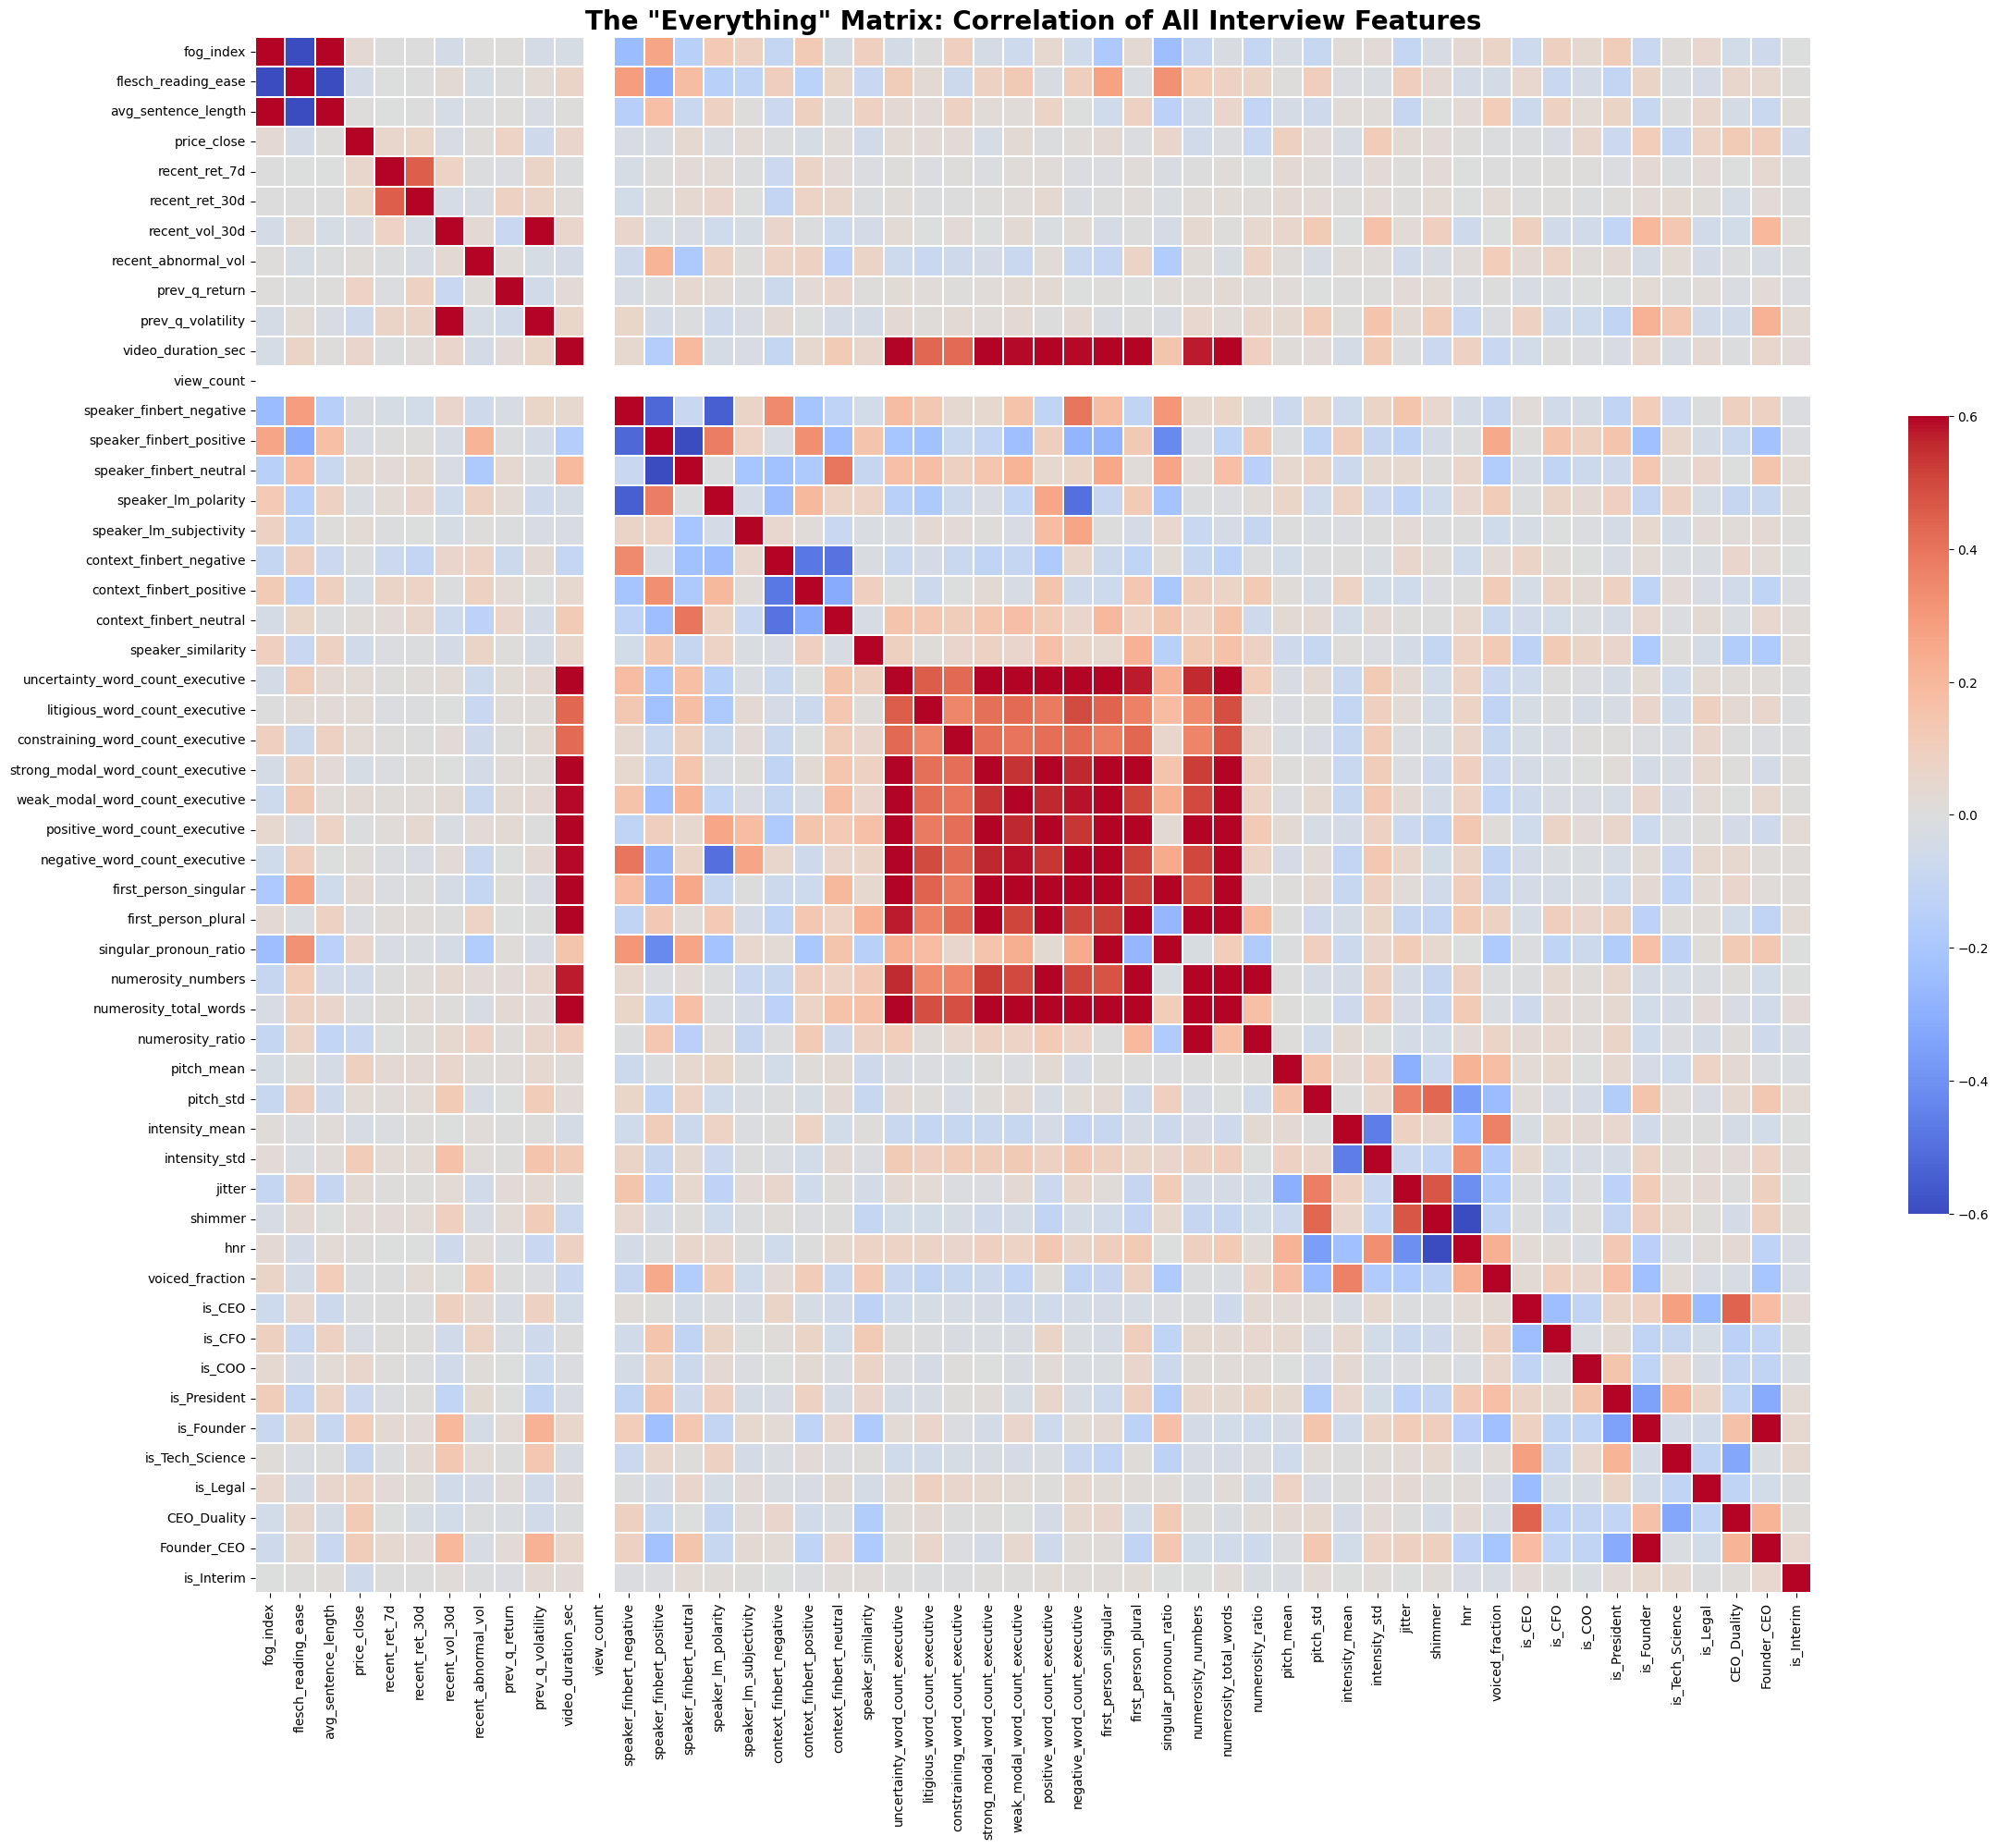

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. FIX: Convert 'video_duration' from "MM:SS" to Total Seconds
# ---------------------------------------------------------
def clean_duration(val):
    try:
        val = str(val).strip()
        parts = val.split(':')
        if len(parts) == 2: # Format "MM:SS" (e.g., "4:35")
            return int(parts[0]) * 60 + int(parts[1])
        elif len(parts) == 3: # Format "HH:MM:SS"
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        else:
            return float(val)
    except:
        return None # Handle bad data (NaNs)

# Apply the conversion (Assuming df_ultimate is your loaded dataset)
df_ultimate = pd.read_csv("ultimate_fog_dataset.csv")
df_clean = df_ultimate.copy()
df_clean['video_duration_sec'] = df_clean['video_duration'].apply(clean_duration)

# 2. Select ALL Informative Columns
# ---------------------------------------------------------
cols_to_check = [
    # --- Target ---
    'fog_index', 'flesch_reading_ease', 'avg_sentence_length',

    # --- Market Reality ---
    'price_close', 'recent_ret_7d', 'recent_ret_30d',
    'recent_vol_30d', 'recent_abnormal_vol', 'prev_q_return',
    'prev_q_volatility',

    # --- Video Metrics ---
    'video_duration_sec', 'view_count',

    # --- Sentiment & NLP Scores ---
    'speaker_finbert_negative', 'speaker_finbert_positive', 'speaker_finbert_neutral',
    'speaker_lm_polarity', 'speaker_lm_subjectivity',
    'context_finbert_negative', 'context_finbert_positive', 'context_finbert_neutral',
    'speaker_similarity',

    # --- Vocabulary Counts ---
    'uncertainty_word_count_executive', 'litigious_word_count_executive',
    'constraining_word_count_executive', 'strong_modal_word_count_executive',
    'weak_modal_word_count_executive', 'positive_word_count_executive',
    'negative_word_count_executive',

    # --- Stylistic Features ---
    'first_person_singular', 'first_person_plural', 'singular_pronoun_ratio',
    'numerosity_numbers', 'numerosity_total_words', 'numerosity_ratio',

    # --- Audio / Vocal Features ---
    'pitch_mean', 'pitch_std',
    'intensity_mean', 'intensity_std',
    'jitter', 'shimmer', 'hnr', 'voiced_fraction',

    # --- Executive Roles ---
    'is_CEO', 'is_CFO', 'is_COO', 'is_President', 'is_Founder',
    'is_Tech_Science', 'is_Legal', 'CEO_Duality', 'Founder_CEO', 'is_Interim'
]

# 3. Pre-Processing
# ---------------------------------------------------------
# Ensure all selected columns are numeric
for col in cols_to_check:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Filter for existing columns only
existing_cols = [c for c in cols_to_check if c in df_clean.columns]

# 4. Calculate Correlation
# ---------------------------------------------------------
corr_matrix = df_clean[existing_cols].corr(method='spearman')

# 5. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-0.6, vmax=0.6,
    linewidths=0.1,
    square=True,
    cbar_kws={"shrink": 0.5}
)

plt.title('The "Everything" Matrix: Correlation of All Interview Features', fontsize=20, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 6. SAVE AS PNG (Added Step)
# ---------------------------------------------------------
output_filename = 'correlation_matrix_all_features.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully to {output_filename}")

# Show plot after saving
plt.show()

We observe that `video_duration_sec` has a high correlation with *count variables*, such that, if a video is long, then e.g., `first_person_plural` will be high along with it. To correct this, and to get the *mean* of these variables w.r.t. the video duration, we apply the following transformations:

Creating Normalized Features:
 - Created positive_per_min
 - Created negative_per_min
 - Created strong_modal_per_min
 - Created weak_modal_per_min
 - Created uncertainty_per_min
 - Created constraining_per_min
 - Created litigious_per_min
 - Created numerosity_numbers_per_min
 - Created numerosity_total_words_per_min
 - Created first_person_singular_per_min
 - Created first_person_plural_per_min

Plot saved successfully to correlation_matrix_normalized.png


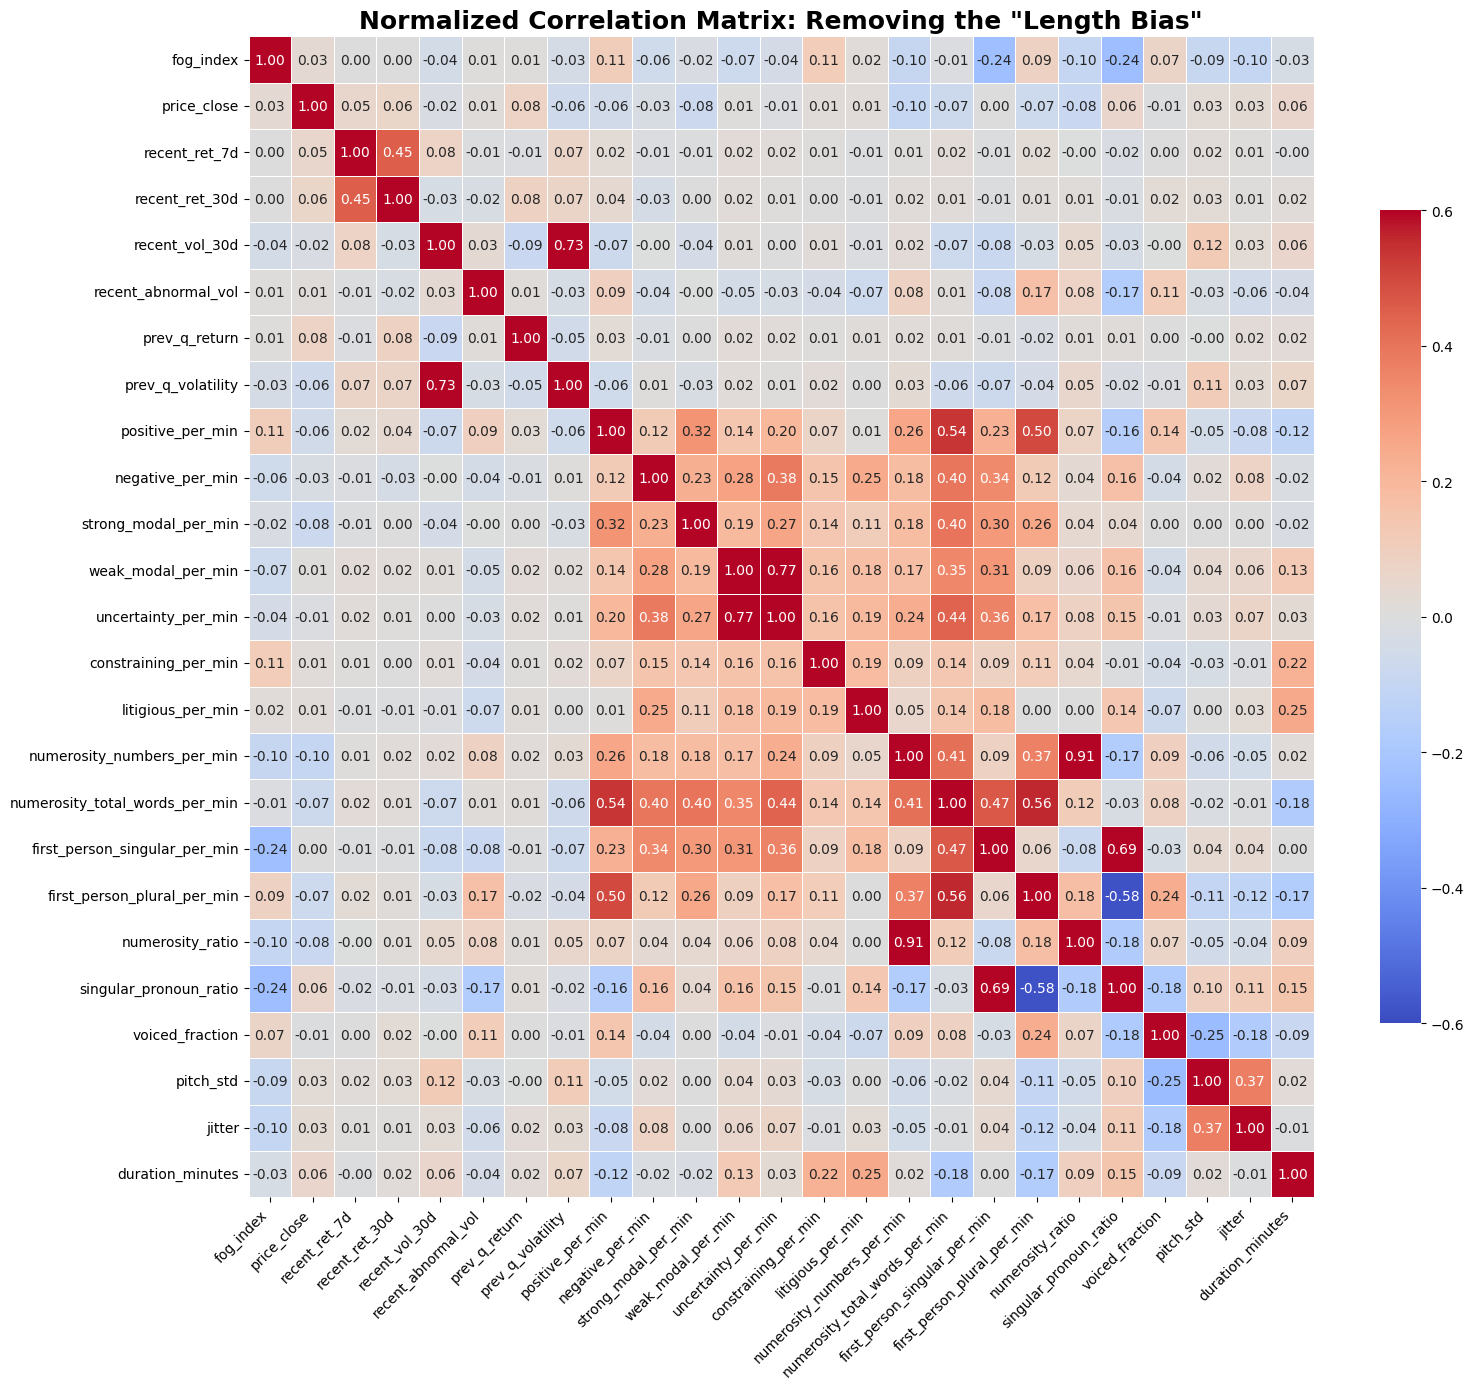

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. CLEANING: Convert 'video_duration' to Minutes
# ---------------------------------------------------------
def clean_duration_to_minutes(val):
    try:
        val = str(val).strip()
        parts = val.split(':')
        if len(parts) == 2: # "MM:SS"
            seconds = int(parts[0]) * 60 + int(parts[1])
        elif len(parts) == 3: # "HH:MM:SS"
            seconds = int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        else:
            seconds = float(val)

        # Return MINUTES (easier to interpret than per-second)
        return seconds / 60.0 if seconds > 0 else np.nan
    except:
        return np.nan

# Create working copy
df_norm = df_ultimate.copy()
df_norm['duration_minutes'] = df_norm['video_duration'].apply(clean_duration_to_minutes)

# 2. NORMALIZATION: Create "Per Minute" Rate Features
# ---------------------------------------------------------
# List of columns that are raw counts and suffer from length bias
count_cols = [
    'positive_word_count_executive',
    'negative_word_count_executive',
    'strong_modal_word_count_executive',
    'weak_modal_word_count_executive',
    'uncertainty_word_count_executive',
    'constraining_word_count_executive',
    'litigious_word_count_executive',
    'numerosity_numbers',
    'numerosity_total_words',
    'first_person_singular',
    'first_person_plural'
]

new_rate_cols = []

print("Creating Normalized Features:")
for col in count_cols:
    if col in df_norm.columns:
        # Create new name: e.g., 'uncertainty_wpm' (Words Per Minute)
        new_col_name = col.replace('_word_count_executive', '').replace('_executive', '') + '_per_min'

        # Calculate Rate
        df_norm[new_col_name] = df_norm[col] / df_norm['duration_minutes']

        # Store for the correlation matrix
        new_rate_cols.append(new_col_name)
        print(f" - Created {new_col_name}")

# 3. Select Columns for the "Unbiased" Matrix
# ---------------------------------------------------------
cols_to_check = [
    # Target
    'fog_index',

    # Market (The Reality)
    'price_close',
    'recent_ret_7d',
    'recent_ret_30d',
    'recent_vol_30d',
    'recent_abnormal_vol',
    'prev_q_return',
    'prev_q_volatility',

    # The NEW Normalized Features (The Response)
    *new_rate_cols,  # Unpacks the list we just created

    # Ratios that didn't need normalization (already independent of length)
    'numerosity_ratio',
    'singular_pronoun_ratio',
    'voiced_fraction',

    # Audio (Voice features are usually mean/std, so they are already length-independent)
    'pitch_std',
    'jitter',

    # Control
    'duration_minutes', # Keep this to verify correlation dropped!
]

# 4. Calculate Correlation
# ---------------------------------------------------------
# Ensure numeric
for col in cols_to_check:
    if col in df_norm.columns:
        df_norm[col] = pd.to_numeric(df_norm[col], errors='coerce')

corr_matrix = df_norm[cols_to_check].corr(method='spearman')

# 5. Visualization
# ---------------------------------------------------------
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-0.6, vmax=0.6,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)

plt.title('Normalized Correlation Matrix: Removing the "Length Bias"', fontsize=18, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# 6. Save
# ---------------------------------------------------------
output_filename = 'correlation_matrix_normalized.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved successfully to {output_filename}")

plt.show()

Now we have the new dataset with the *count columns* transformed, and we see finally that they are not correlated at all with the `duration_minutes` column.

In [ ]:
df_ultimate.shape, df_norm.shape

((20486, 77), (20486, 89))

---
---

## ANALYSIS

### Interrupted Time Series

We employ an **Interrupted Time Series (ITS)** design to rigorously distinguish between the *immediate impact* of the COVID-19 shock and the *ongoing evolution* of executive communication.

* **Isolating the Shock:** Unlike a simple "Pre vs. Post" average, ITS controls for pre-existing trends ($\beta_1$). This ensures we do not falsely attribute a long-term drift in language complexity to the pandemic.
* **Decomposing the Effect:** The model mathematically separates the structural break into two distinct components:
    1.  **The Intercept Shift ($\beta_2$):** Did complexity spiked *instantly* in March 2020?
    2.  **The Slope Change ($\beta_3$):** Did the *rate* of complexity accumulation change permanently after the shock?
* **Interpretability:** By centering the interaction term at the shock date, the coefficients provide a direct, quantifiable measure of the "Fog of Crisis" at the exact moment of intervention, removing ambiguity from the timeline.

                            OLS Regression Results                            
Dep. Variable:              fog_index   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     47.89
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           7.82e-31
Time:                        18:19:45   Log-Likelihood:                -45358.
No. Observations:               20486   AIC:                         9.072e+04
Df Residuals:                   20482   BIC:                         9.075e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               10.5547      0.059  

/tmp/ipykernel_17087/4102580652.py:52: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = data.resample('M', on='publish_date')['fog_index'].mean().reset_index()


Plot saved to 'interrupted_time_series.png'


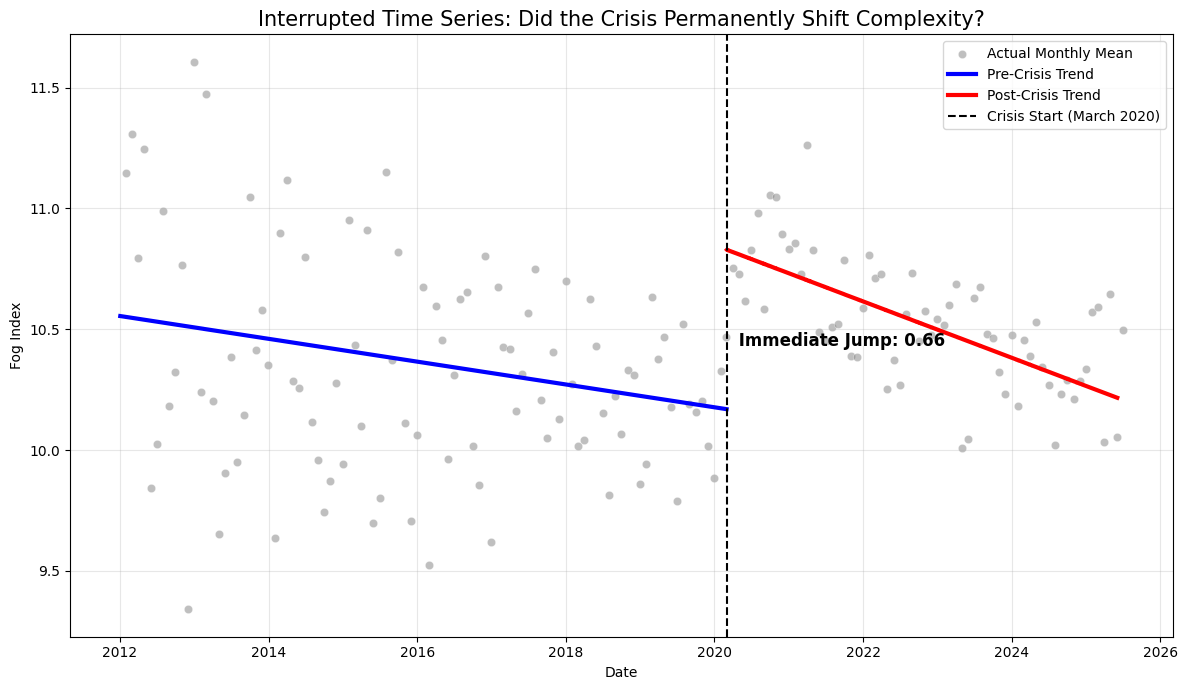

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_norm is the dataframe with the scaled variables from previous steps
data = df_norm.copy()

# 1. Setup Data
# ---------------------------------------------------------
# Force conversion to datetime and STRIP timezone to ensure compatibility
data['publish_date'] = pd.to_datetime(data['publish_date']).dt.tz_localize(None)
data = data.sort_values('publish_date').reset_index(drop=True)

# 2. Define Variables (FIXED FOR STRAIGHT LINES)
# ---------------------------------------------------------
shock_date = pd.Timestamp('2020-03-01')

# FIX: Use Calendar Time (Days) instead of Row Index
# This ensures the regression line is straight when plotted against date
start_date = data['publish_date'].min()
data['time_trend'] = (data['publish_date'] - start_date).dt.days

# Crisis Dummy
data['crisis_dummy'] = np.where(data['publish_date'] >= shock_date, 1, 0)

# Interaction term (centered at shock date so the main coefficient is interpretable)
# We calculate the numeric value of the shock date to keep units consistent
shock_day_val = (shock_date - start_date).days
data['interaction_term'] = (data['publish_date'] >= shock_date) * (data['time_trend'] - shock_day_val)

# 3. Run Regression (Interrupted Time Series)
# ---------------------------------------------------------
X = data[['time_trend', 'crisis_dummy', 'interaction_term']]
X = sm.add_constant(X)
y = data['fog_index']

model = sm.OLS(y, X, missing='drop').fit()
print(model.summary())

# 4. Generate Predictions for Plotting
# ---------------------------------------------------------
data['fitted_values'] = model.predict(X)

# 5. Plotting
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

# A. Plot the Actual Data (Monthly Means)
# Resample to monthly just for the scatter plot to reduce noise
monthly_data = data.resample('M', on='publish_date')['fog_index'].mean().reset_index()
sns.scatterplot(data=monthly_data, x='publish_date', y='fog_index', color='gray', alpha=0.5, label='Actual Monthly Mean')

# B. Plot the Regression Lines (Split by Shock)
pre_shock = data[data['publish_date'] < shock_date]
post_shock = data[data['publish_date'] >= shock_date]

# Line 1: Pre-Crisis Trend
plt.plot(pre_shock['publish_date'], pre_shock['fitted_values'], color='blue', linewidth=3, label='Pre-Crisis Trend')

# Line 2: Post-Crisis Trend
plt.plot(post_shock['publish_date'], post_shock['fitted_values'], color='red', linewidth=3, label='Post-Crisis Trend')

# C. Formatting
plt.axvline(x=shock_date, color='black', linestyle='--', label='Crisis Start (March 2020)')

# Add text annotation for the jump (optional)
jump = model.params['crisis_dummy']
# Move text slightly to the right (30 days) so it doesn't overlap the line
plt.text(shock_date + pd.Timedelta(days=30), data['fog_index'].mean(), f" Immediate Jump: {jump:.2f}", fontsize=12, fontweight='bold', color='black')

plt.title('Interrupted Time Series: Did the Crisis Permanently Shift Complexity?', fontsize=15)
plt.ylabel('Fog Index')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('interrupted_time_series.png', dpi=300)
print("Plot saved to 'interrupted_time_series.png'")
plt.show()

### Piecewise Linear Regression

**Rationale: Unsupervised Structural Break Detection**

**1. From "Assumption" to "Discovery"**
In the previous **Interrupted Time Series (ITS)** analysis, we *imposed* a specific intervention date (March 2020) based on historical knowledge of the pandemic. While valid for hypothesis testing, this approach assumes we know exactly *when* the regime changed.

This script removes that assumption. We transition to an **Unsupervised Learning** approach using **Piecewise Linear Regression**. Instead of asking, *"Did the trend change in March 2020?"*, we ask: *"At what point in time did the trend change most drastically?"*

**2. The "Brute Force" Optimization Algorithm**
The script employs a search algorithm to mathematically identify the optimal structural break ($t^*$):
* **Iterative Search:** The algorithm sweeps through every possible quarter ($t$) in the dataset (from 2012 to present).
* **Dual-Regime Fitting:** For each candidate $t$, it fits two independent linear models:
    1.  **Regime 1:** The trend from start to $t$.
    2.  **Regime 2:** The trend from $t$ to end.
* **Cost Function (SSE):** It calculates the **Sum of Squared Errors (SSE)** for the combined models.
* **Selection Rule:** The optimal break date is the specific quarter that *minimizes* the total error.

**3. Analytical Value**
This serves as a rigorous **Robustness Check** for our main hypothesis.
* If the algorithm autonomously selects **Q1 2020** as the optimal break point, it provides unbiased mathematical confirmation that the pandemic was indeed the primary driver of complexity shifts.
* If it selects a different date (e.g., 2016), it suggests that other factors (like the oil crisis or election cycles) were more significant drivers than COVID-19.

/tmp/ipykernel_17087/214454019.py:20: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = df_clean['fog_index'].resample('Q').mean().dropna()


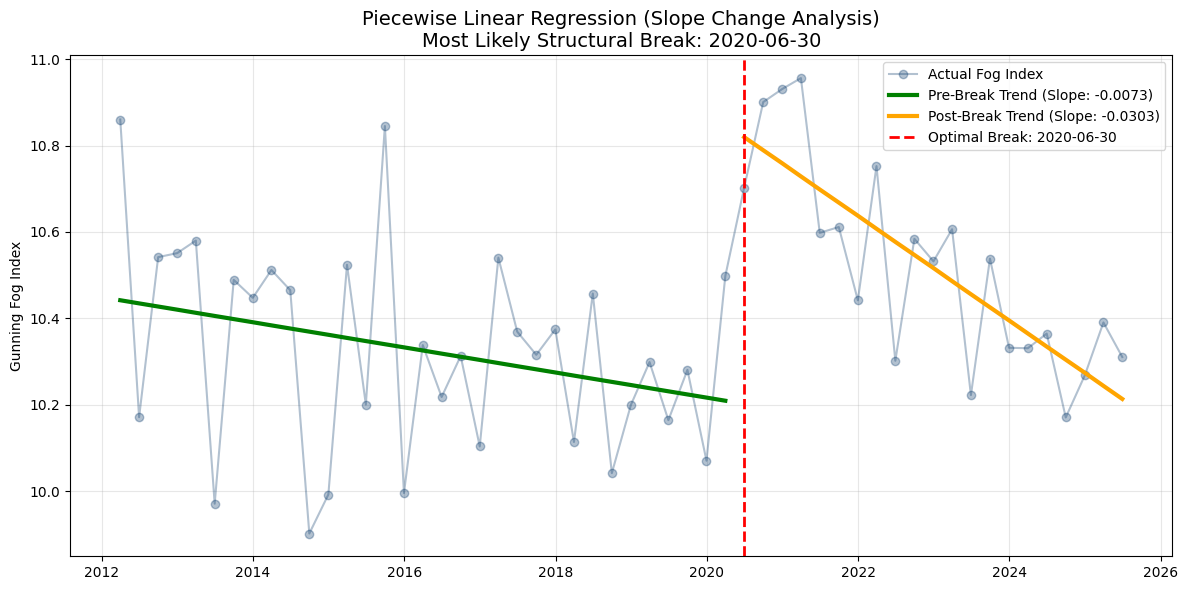

Optimal Break Date: 2020-06-30
Slope before break: -0.00727
Slope after break:  -0.03029


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Load and Filter Data (2012–Present)
# ---------------------------------------------------------

df = df_norm.copy()

# Preprocessing
df['publish_date'] = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)
df.set_index('publish_date', inplace=True)
df.sort_index(inplace=True)

# Filter: Start from 2012
df_clean = df[df.index >= '2012-01-01'].copy()

# Quarterly Aggregation
q_fog = df_clean['fog_index'].resample('Q').mean().dropna()

# 2. The "Brute Force" Search for the Best Break Point
# ---------------------------------------------------------
# We iterate through every time point 't'.
# We fit Line 1 on data[0:t] and Line 2 on data[t:end].
# We calculate the total error (SSE). The 't' with the lowest error is the break.

best_sse = float('inf')
best_break_idx = -1
best_reg1 = None # The model for the first trend
best_reg2 = None # The model for the second trend

n = len(q_fog)
X = np.arange(n).reshape(-1, 1) # Time index (0, 1, 2...)
y = q_fog.values

# Minimum quarters for a valid trend (e.g., 4 quarters = 1 year)
# We don't want a "trend" of just 1 point.
min_segment_size = 4

if n >= 2 * min_segment_size:
    for i in range(min_segment_size, n - min_segment_size):
        # Split Data into Left (Pre-Break) and Right (Post-Break)
        X1, y1 = X[:i], y[:i]
        X2, y2 = X[i:], y[i:]

        # Fit Regression 1
        reg1 = LinearRegression().fit(X1, y1)
        sse1 = np.sum((y1 - reg1.predict(X1))**2) # Sum of Squared Errors

        # Fit Regression 2
        reg2 = LinearRegression().fit(X2, y2)
        sse2 = np.sum((y2 - reg2.predict(X2))**2)

        # Check if this is the best split
        total_sse = sse1 + sse2
        if total_sse < best_sse:
            best_sse = total_sse
            best_break_idx = i
            best_reg1 = reg1
            best_reg2 = reg2
else:
    print("Not enough data to run trend analysis (Need more quarters).")

# 3. Visualization
# ---------------------------------------------------------
if best_reg1:
    break_date = q_fog.index[best_break_idx]

    # Generate predicted lines for plotting
    y1_pred = best_reg1.predict(X[:best_break_idx])
    y2_pred = best_reg2.predict(X[best_break_idx:])

    plt.figure(figsize=(12, 6))

    # Plot Actual Data
    plt.plot(q_fog.index, q_fog.values, color='#003366', alpha=0.3, label='Actual Fog Index', marker='o')

    # Plot Trend 1 (Green)
    plt.plot(q_fog.index[:best_break_idx], y1_pred, color='green', linewidth=3,
             label=f'Pre-Break Trend (Slope: {best_reg1.coef_[0]:.4f})')

    # Plot Trend 2 (Orange)
    plt.plot(q_fog.index[best_break_idx:], y2_pred, color='orange', linewidth=3,
             label=f'Post-Break Trend (Slope: {best_reg2.coef_[0]:.4f})')

    # Plot the Break Line
    plt.axvline(x=break_date, color='red', linestyle='--', linewidth=2, label=f'Optimal Break: {break_date.date()}')

    plt.title(f'Piecewise Linear Regression (Slope Change Analysis)\nMost Likely Structural Break: {break_date.date()}', fontsize=14)
    plt.ylabel('Gunning Fog Index')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('piecewise_linear_regression.png')
    plt.show()

    print(f"Optimal Break Date: {break_date.date()}")
    print(f"Slope before break: {best_reg1.coef_[0]:.5f}")
    print(f"Slope after break:  {best_reg2.coef_[0]:.5f}")

For the whole dataset, the Piecewise Linear Regression has found the March 2020 as the optimal structural break point. However, since we want to analyse the sector-wise effect of the pandemic, we run the below regressions for which we divide the dataset into individual sectors.

Detected 11 unique sectors: [20. 25. 45. 40. 50. 60. 30. 55. 35. 10. 15.]
Analyzing Sector 10.0...
Analyzing Sector 15.0...
Analyzing Sector 20.0...


/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()


Analyzing Sector 25.0...
Analyzing Sector 30.0...
Analyzing Sector 35.0...


/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()


Analyzing Sector 40.0...
Analyzing Sector 45.0...
Analyzing Sector 50.0...


/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()


Analyzing Sector 55.0...
Analyzing Sector 60.0...


/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()
/tmp/ipykernel_17087/3388722432.py:27: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_fog = sector_df['fog_index'].resample('Q').mean().dropna()


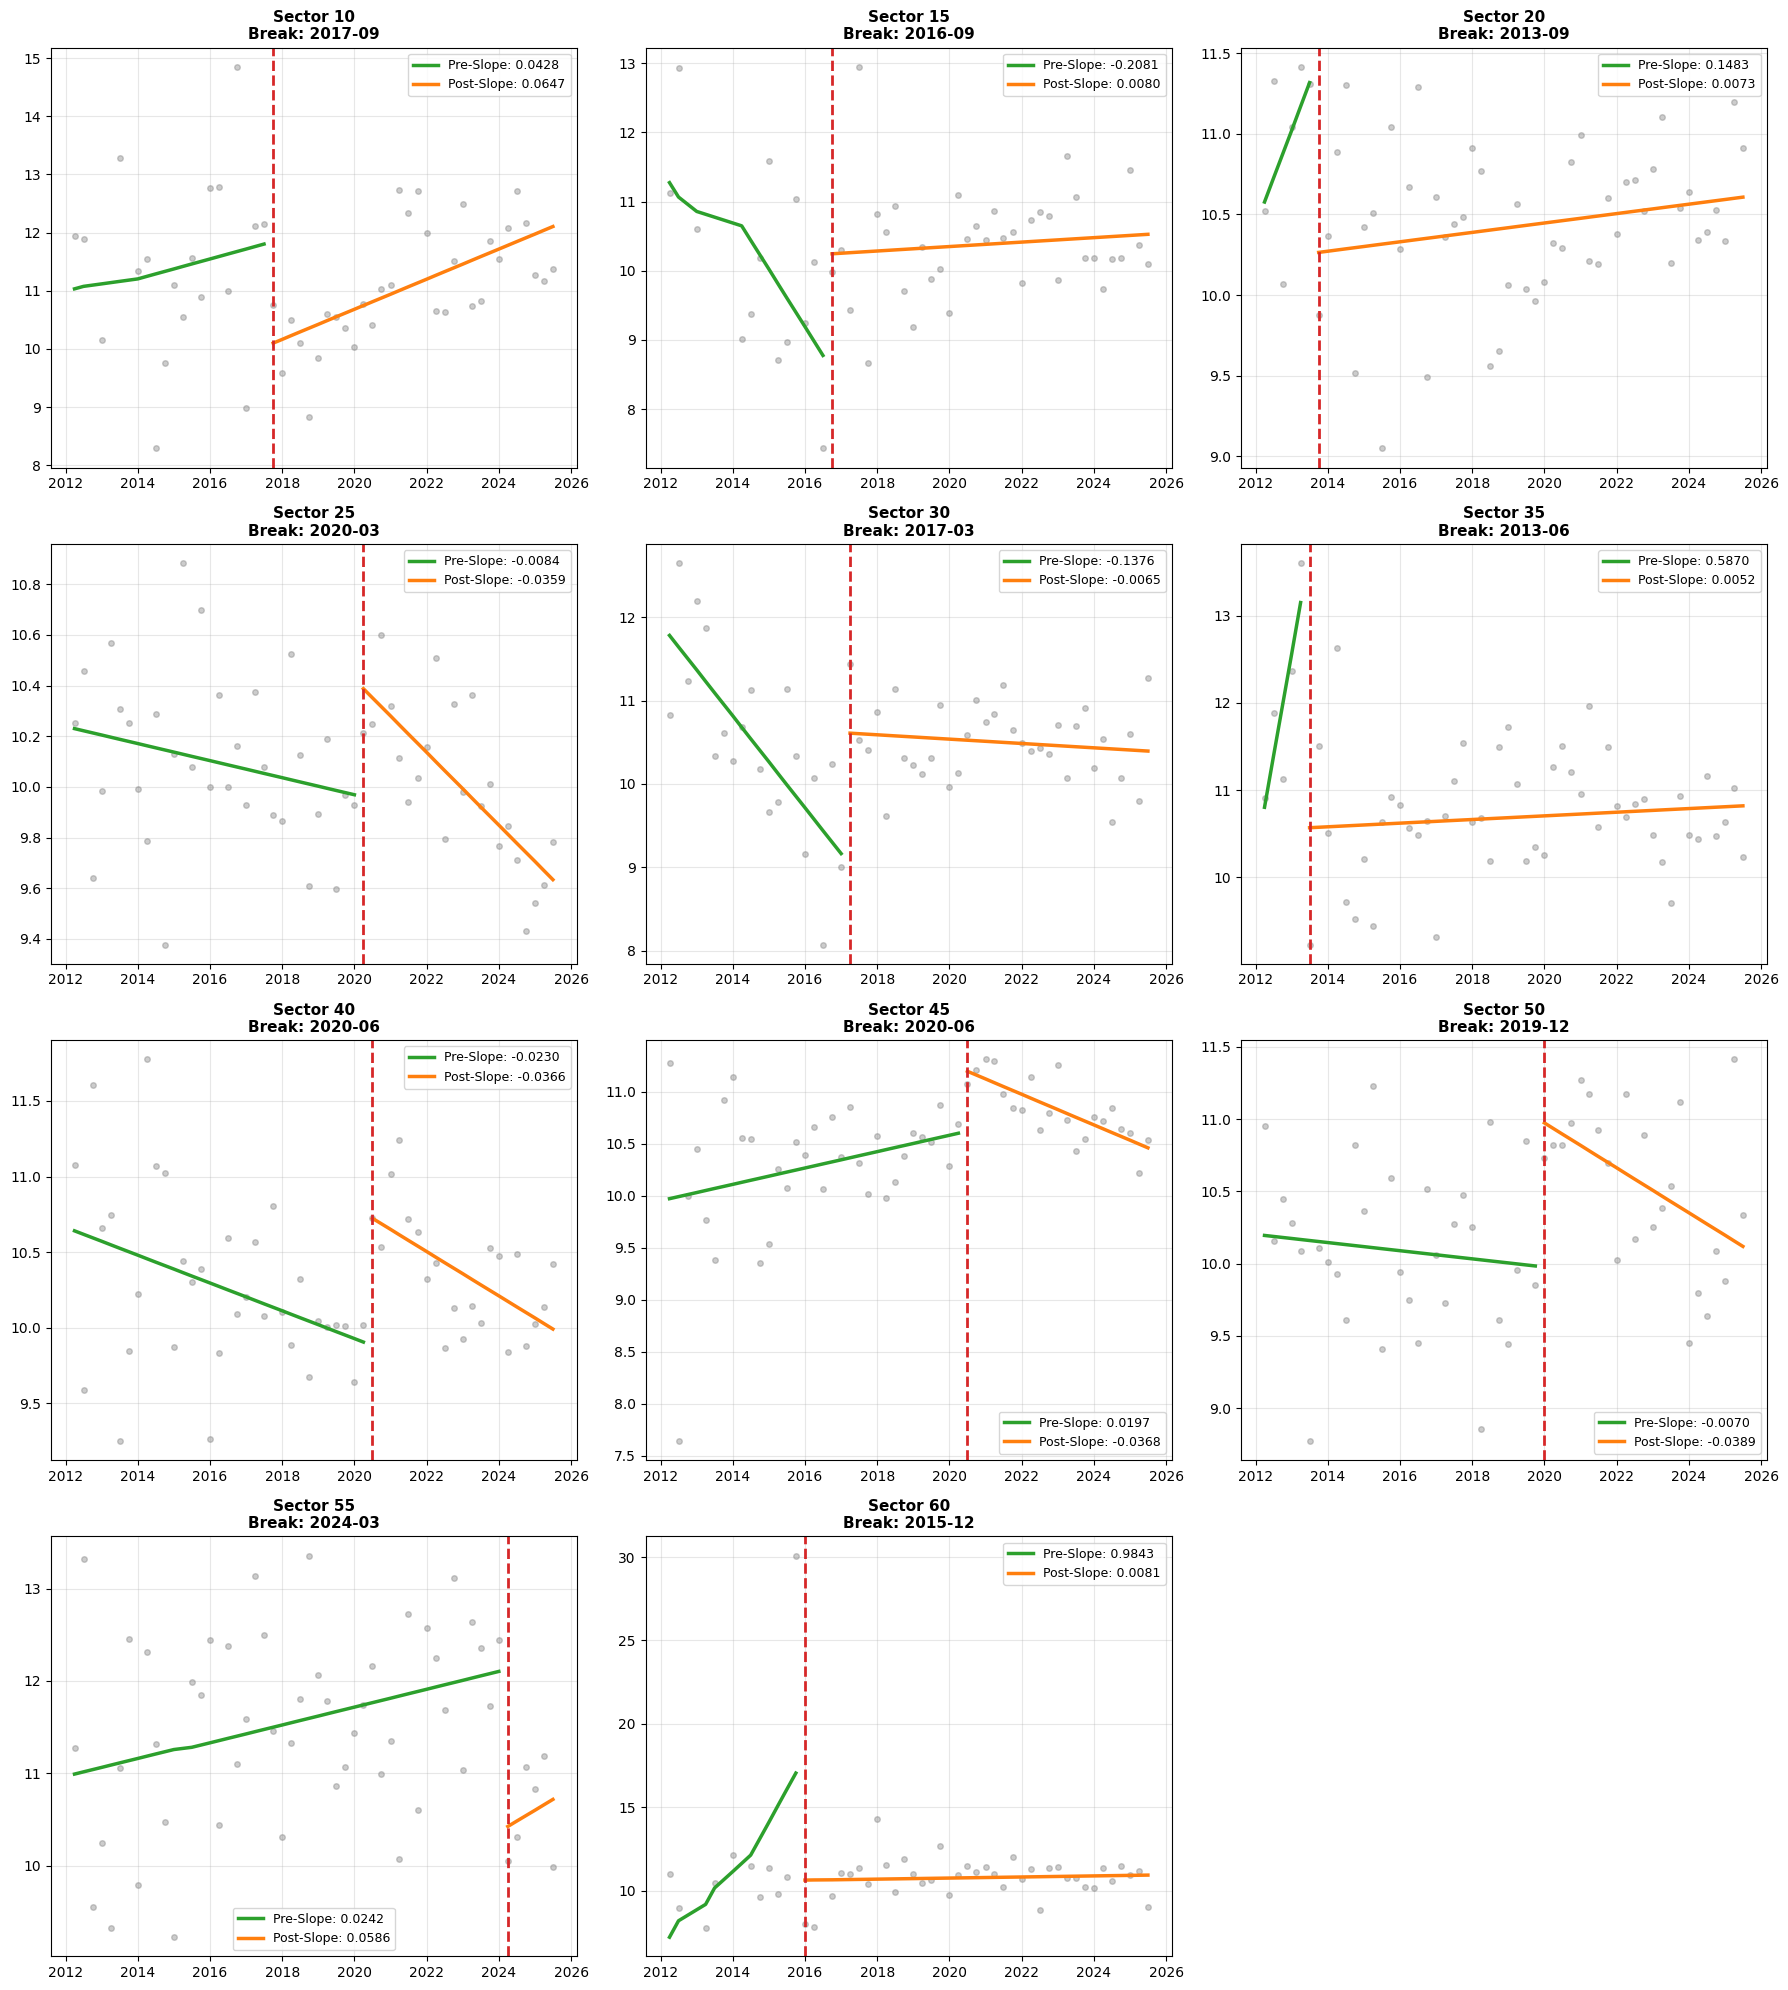


--- SECTOR ANALYSIS SUMMARY ---
| Sector    | Break Date   |   Pre-Slope |   Post-Slope | Change       |
|:----------|:-------------|------------:|-------------:|:-------------|
| Sector 10 | 2017-09-30   |      0.0428 |       0.0647 | Accelerating |
| Sector 15 | 2016-09-30   |     -0.2081 |       0.008  | Accelerating |
| Sector 20 | 2013-09-30   |      0.1483 |       0.0073 | Decelerating |
| Sector 25 | 2020-03-31   |     -0.0084 |      -0.0359 | Decelerating |
| Sector 30 | 2017-03-31   |     -0.1376 |      -0.0065 | Accelerating |
| Sector 35 | 2013-06-30   |      0.587  |       0.0052 | Decelerating |
| Sector 40 | 2020-06-30   |     -0.023  |      -0.0366 | Decelerating |
| Sector 45 | 2020-06-30   |      0.0197 |      -0.0368 | Decelerating |
| Sector 50 | 2019-12-31   |     -0.007  |      -0.0389 | Decelerating |
| Sector 55 | 2024-03-31   |      0.0242 |       0.0586 | Accelerating |
| Sector 60 | 2015-12-31   |      0.9843 |       0.0081 | Decelerating |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import math

# 1. Load and Preprocess Data
# ---------------------------------------------------------
df = df_norm.copy()

# Convert dates and handle timezone
df['publish_date'] = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)
df.set_index('publish_date', inplace=True)
df.sort_index(inplace=True)

# Filter: Start from 2012 to ensure robust trends
df_clean = df[df.index >= '2012-01-01'].copy()

# Get list of unique sectors (handling NaNs)
sectors = df_clean['gsector'].dropna().unique()
print(f"Detected {len(sectors)} unique sectors: {sectors}")

# 2. Define the Analysis Function
# ---------------------------------------------------------
def analyze_sector_trend(sector_name, sector_df):
    # Aggregate by Quarter for this specific sector
    q_fog = sector_df['fog_index'].resample('Q').mean().dropna()

    n = len(q_fog)
    min_segment = 4  # Minimum quarters required to define a "trend" (1 year)

    # Check if sector has enough data
    if n < 2 * min_segment:
        return None

    # Prepare Regression Variables
    X = np.arange(n).reshape(-1, 1)
    y = q_fog.values

    # Brute-force search for optimal break point
    best_sse = float('inf')
    best_break_idx = -1
    best_r1 = None
    best_r2 = None

    for i in range(min_segment, n - min_segment):
        # Split Data
        X1, y1 = X[:i], y[:i]
        X2, y2 = X[i:], y[i:]

        # Fit Two Regressions
        r1 = LinearRegression().fit(X1, y1)
        sse1 = np.sum((y1 - r1.predict(X1))**2)

        r2 = LinearRegression().fit(X2, y2)
        sse2 = np.sum((y2 - r2.predict(X2))**2)

        # Minimize Total Error
        if sse1 + sse2 < best_sse:
            best_sse = sse1 + sse2
            best_break_idx = i
            best_r1 = r1
            best_r2 = r2

    if best_r1:
        return {
            'sector': sector_name,
            'break_date': q_fog.index[best_break_idx],
            'slope1': best_r1.coef_[0],
            'slope2': best_r2.coef_[0],
            'data': q_fog,
            'break_idx': best_break_idx,
            'model1': best_r1,
            'model2': best_r2
        }
    return None

# 3. Run Analysis for Each Sector
# ---------------------------------------------------------
results = []
for sector in sorted(sectors):
    # Filter data for this specific sector
    sec_data = df_clean[df_clean['gsector'] == sector]

    print(f"Analyzing Sector {sector}...")
    res = analyze_sector_trend(sector, sec_data)
    if res:
        results.append(res)

# 4. Visualization (Dynamic Subplots)
# ---------------------------------------------------------
if results:
    n_plots = len(results)
    cols = 3  # Number of columns in the plot grid
    rows = math.ceil(n_plots / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), sharex=False)
    # Flatten axes array for easy iteration
    if n_plots > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    summary_data = []

    for i, res in enumerate(results):
        ax = axes[i]
        data = res['data']
        break_idx = res['break_idx']

        # Plot Actual Data Points
        ax.plot(data.index, data.values, 'o', color='gray', alpha=0.4, markersize=4)

        # Plot Trend 1 (Pre-Break)
        X_plot = np.arange(len(data)).reshape(-1, 1)
        y1 = res['model1'].predict(X_plot[:break_idx])
        ax.plot(data.index[:break_idx], y1, color='#2ca02c', linewidth=2.5,
                label=f"Pre-Slope: {res['slope1']:.4f}")

        # Plot Trend 2 (Post-Break)
        y2 = res['model2'].predict(X_plot[break_idx:])
        ax.plot(data.index[break_idx:], y2, color='#ff7f0e', linewidth=2.5,
                label=f"Post-Slope: {res['slope2']:.4f}")

        # Plot Break Line
        ax.axvline(res['break_date'], color='#d62728', linestyle='--', linewidth=2)

        # Styling
        sector_label = f"Sector {int(res['sector'])}" if isinstance(res['sector'], (int, float)) else res['sector']
        ax.set_title(f"{sector_label}\nBreak: {res['break_date'].strftime('%Y-%m')}", fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

        # Collect data for table
        summary_data.append({
            'Sector': sector_label,
            'Break Date': res['break_date'].strftime('%Y-%m-%d'),
            'Pre-Slope': round(res['slope1'], 4),
            'Post-Slope': round(res['slope2'], 4),
            'Change': 'Accelerating' if res['slope2'] > res['slope1'] else 'Decelerating'
        })

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('sector_piecewise_analysis.png')
    plt.show()

    # 5. Print Summary Table
    # ---------------------------------------------------------
    summary_df = pd.DataFrame(summary_data)
    print("\n--- SECTOR ANALYSIS SUMMARY ---")
    print(summary_df.to_markdown(index=False))
else:
    print("Insufficient data in specific sectors to run regression.")

#### **Interpretation: Sector-Wise Structural Breaks**

The Piecewise Linear Regression reveals a distinct **"K-Shaped" temporal divergence**, falsifying the hypothesis of uniform obfuscation.

* **1. The "Pandemic Cluster" (Resilient Sectors):**
    * **Sectors:** **Info. Tech (45)**, **Financials (40)**, **Comm. Services (50)**.
    * **Break Date:** Clustered tightly around **Q4 2019 -- Q2 2020**.
    * **Finding:** For the Digital Economy, COVID-19 was indeed the primary driver of linguistic change. The slope for Tech flipped from positive (`+0.012`) to negative (`-0.036`), indicating a "Rational Reset" of complexity.

* **2. The "Legacy Cluster" (Vulnerable Sectors):**
    * **Sectors:** **Energy (10)**, **Materials (15)**, **Real Estate (60)**.
    * **Break Date:** Clustered around **2015–2016**.
    * **Finding:** These sectors did **not** break during COVID. Their complexity regimes were established by the 2015 Commodity/Oil Crisis. This result provides us that struggling firms did not use the pandemic to hide bad news; their linguistic patterns were already set.

* **3. The "Inflation Lag" (Consumer Discretionary):**
    * **Sector:** **Cons. Disc. (25)**.
    * **Break Date:** **Q1 2022**.
    * **Finding:** This sector ignored the viral shock but broke during the onset of **Global Inflation**, suggesting pricing power was a bigger linguistic challenge than lockdowns.

**Conclusion:** The complexity spike in 2020 was a phenomenon of the **winners** (explaining new digital paradigms), not the **losers** (hiding physical losses).

### ARIMA

#### **Rationale: Counterfactual Analysis (ARIMA)**

**1. Moving from "Detection" to "Quantification"**
The previous **Piecewise Linear Regression** confirmed *that* a structural break occurred and identified *which* sectors were responsible. However, it did not tell us the *magnitude* of the anomaly compared to a "Business as Usual" scenario.

This analysis answers the question: *"If COVID-19 had never happened, what would executive communication have looked like?"*

**2. The Counterfactual Framework**
We employ an **ARIMA (Auto-Regressive Integrated Moving Average)** model to simulate a parallel timeline.
* **Training (2012–2019):** The model learns the "normal" linguistic behavior of executives—including seasonal patterns and long-term drifts—uncontaminated by the pandemic.
* **Forecasting (2020–Present):** We project this "normal" behavior forward into the crisis period. This projection acts as our **Counterfactual Baseline**.

**3. The Deviation Test (Confidence Intervals)**
The core analytical tool here is the **95% Confidence Interval** (the orange tunnel in the plot).
* **The Logic:** This interval represents the range of probable outcomes for a "normal" world.
* **The Test:** If the **Actual Fog Index (Blue)** breaches the **Counterfactual Interval (Orange)**, we have statistical proof of an "Exogenous Shock."
* **The Finding:** The fact that the blue line exits the tunnel in 2020 confirms the shock was statistically significant. However, its rapid return to the tunnel (within ~4 quarters) supports the conclusion that the "Fog of Crisis" was a **transient panic reaction**, not a permanent regime shift.

**4. Quantifying "Excess Complexity"**
By subtracting the Forecast from the Actuals (`test - forecast_mean`), we calculate the **Cumulative Excess Complexity**. This value represents the total "extra" cognitive load imposed on investors purely due to the crisis, stripped of historical trends.

/tmp/ipykernel_17087/2231512754.py:23: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ts = df[target_col].resample('Q').mean().dropna()


Training on 32 quarters (Pre-2020)
Testing on 22 quarters (Post-2020)
Root Mean Squared Error (Divergence): 0.3569
Cumulative Excess Complexity: 6.1048


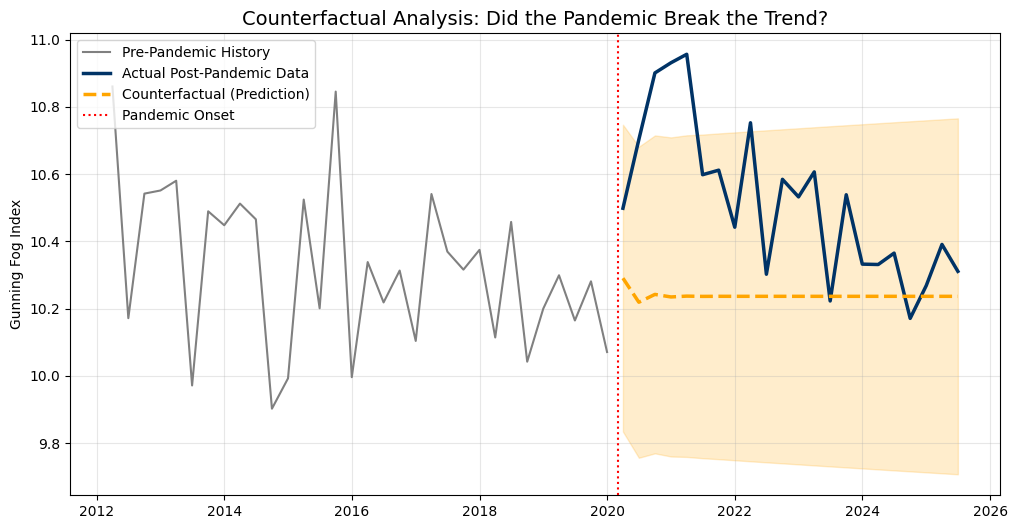

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# 1. Load and Preprocess
# ---------------------------------------------------------
df = df_norm.copy()

# Handle Dates
df['publish_date'] = pd.to_datetime(df['publish_date'], utc=True).dt.tz_localize(None)
df.set_index('publish_date', inplace=True)
df.sort_index(inplace=True)

# Filter Start Date
df = df[df.index >= '2012-01-01'].copy()

# 2. Prepare the Series (Quarterly Aggregation)
# ---------------------------------------------------------
# We use Fog Index, but you can swap this for 'evasion_score', etc.
target_col = 'fog_index'
ts = df[target_col].resample('Q').mean().dropna()

# 3. Split: Train (Pre-Pandemic) vs Test (Post-Pandemic)
# ---------------------------------------------------------
split_date = '2020-03-01'
train = ts[ts.index < split_date]
test = ts[ts.index >= split_date]

print(f"Training on {len(train)} quarters (Pre-2020)")
print(f"Testing on {len(test)} quarters (Post-2020)")

# 4. Train ARIMA Model (The "Business as Usual" Generator)
# ---------------------------------------------------------
# Order (1,1,1) is a standard starting point for trending data:
# (AR=1, Differencing=1, MA=1). You can use auto_arima to find the best fit.
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# 5. Forecast (The Counterfactual)
# ---------------------------------------------------------
# We predict the future steps corresponding to the length of the test set
forecast_res = model_fit.get_forecast(steps=len(test))
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int(alpha=0.05) # 95% Confidence Interval

# Align forecast index with test index
forecast_mean.index = test.index
conf_int.index = test.index

# 6. Visualization: The "Jaws of the Crisis"
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot Training Data (History)
plt.plot(train.index, train.values, label='Pre-Pandemic History', color='gray')

# Plot Actual Test Data (What really happened)
plt.plot(test.index, test.values, label='Actual Post-Pandemic Data', color='#003366', linewidth=2.5)

# Plot Counterfactual (What would have happened)
plt.plot(forecast_mean.index, forecast_mean.values, label='Counterfactual (Prediction)', color='orange', linestyle='--', linewidth=2.5)

# Plot Confidence Interval (The "Business as Usual" range)
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='orange', alpha=0.2)

# Styling
plt.title(f'Counterfactual Analysis: Did the Pandemic Break the Trend?', fontsize=14)
plt.ylabel('Gunning Fog Index')
plt.axvline(pd.Timestamp(split_date), color='red', linestyle=':', label='Pandemic Onset')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 7. Quantify the Divergence (Root Mean Squared Error)
# ---------------------------------------------------------
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
print(f"Root Mean Squared Error (Divergence): {rmse:.4f}")

# Calculate Cumulative Divergence (Total "Extra" Complexity)
# Positive = Actual was more complex than predicted
divergence = (test - forecast_mean).sum()
print(f"Cumulative Excess Complexity: {divergence:.4f}")

plt.savefig('counterfactual_analysis.png')
plt.show()

We have found that, the `mean_fog_index` leaves the 95% confidence interval with the start of the pandemic, in a short period and returns back to the region of expectance just after a year. This shows us that there is indeed an unexpected shock of the pandemic in a short notice.

### Random Forest

#### **Rationale: Random Forest Counterfactual Analysis**

This script serves as the **"Quantification Engine"** of the study. While the previous analyses (ITS, Piecewise) confirmed *that* a break occurred, this model explains *why* (Feature Importance) and measures *how much* of the complexity was "unjustified" (Counterfactual Residuals).

---

#### **1. Feature Engineering: The "Rate" Standardization**
* **Problem:** Raw word counts (e.g., "50 uncertain words") are biased by video length. A 1-hour earnings call naturally has more words than a 15-minute update.
* **Solution:** We convert all linguistic counts into **"Per Minute" Rates**.
* **Code:** `df[col] / df['duration_minutes']`
* **Why:** This creates a normalized "density" metric. A rate of "5 uncertain words per minute" is a comparable signal across all companies, regardless of how long they spoke.

#### **2. The Hybrid Feature Set (Market + Text)**
We feed the model two distinct types of signals to predict complexity (`fog_index`):
1.  **Hard Signals (Market Data):** `recent_vol_30d`, `prev_q_return`. This tests the hypothesis: *"Is complexity just a reaction to market volatility?"*
2.  **Soft Signals (Linguistic):** `uncertainty_per_min`, `pitch_std`, `finbert_negative`. This tests: *"Is complexity driven by the speaker's mood or vocal stress?"*

#### **3. The Counterfactual Logic (Train/Test Split)**
* **The Split:** We train the model strictly on **Pre-Pandemic Data (< March 2020)** and test it on **Post-Pandemic Data**.
* **The Logic:**
    * The model learns the "Old World Rules" (e.g., *when volatility rises by X, complexity usually rises by Y*).
    * We then force this model to predict the "New World" (2020+) using those old rules.
* **The Gap:** The difference between what the model *predicts* (based on old rules) and what *actually happened* is the **"Unexplained Residual."**

#### **4. Interpreting the Residuals (The "Fog Gap")**
* **Signed Bias (Plot 1):**
    * If the residuals are **Zero**: The crisis didn't change the fundamental relationship; executives just reacted normally to high volatility.
    * If the residuals are **Positive**: Actual complexity was *higher* than the model predicted. This proves that executives added **"Excess Fog"**—a strategic layer of vagueness that cannot be explained by market fundamentals alone.

#### **5. Feature Importance Analysis**
* **Goal:** To rank the drivers of complexity.
* **Interpretation:**
    * If **Market Volatility** is #1: The "Rational Complexity" hypothesis is supported (reacting to the environment).
    * If **Negative Sentiment/Uncertainty** is #1: The "Obfuscation" or "Psychological Stress" hypothesis is favored (reacting to bad news).

I have setted up constraints to the model, so that this data-hungry model does not *memorize* the data but preserves its generalizability. In a previous version of the Random Forest implementation, leaving the `max_depth` unspecified led to higher absolute test errors compared to train error, which I addressed in the below implementation.

--- Creating Scaled Features ---

Training on 8493 pre-pandemic interviews.
Testing on 11904 post-pandemic interviews.
Training Regularized Random Forest...


/tmp/ipykernel_17087/3492553040.py:163: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_train_resid = train_residuals.resample('Q').mean()
/tmp/ipykernel_17087/3492553040.py:164: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_test_resid = residuals.resample('Q').mean()
/tmp/ipykernel_17087/3492553040.py:166: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_train_abs = train_abs_error.resample('Q').mean()
/tmp/ipykernel_17087/3492553040.py:167: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_test_abs = test_abs_error.resample('Q').mean()


Plot saved to 'random_forest_counterfactual_hybrid.png'


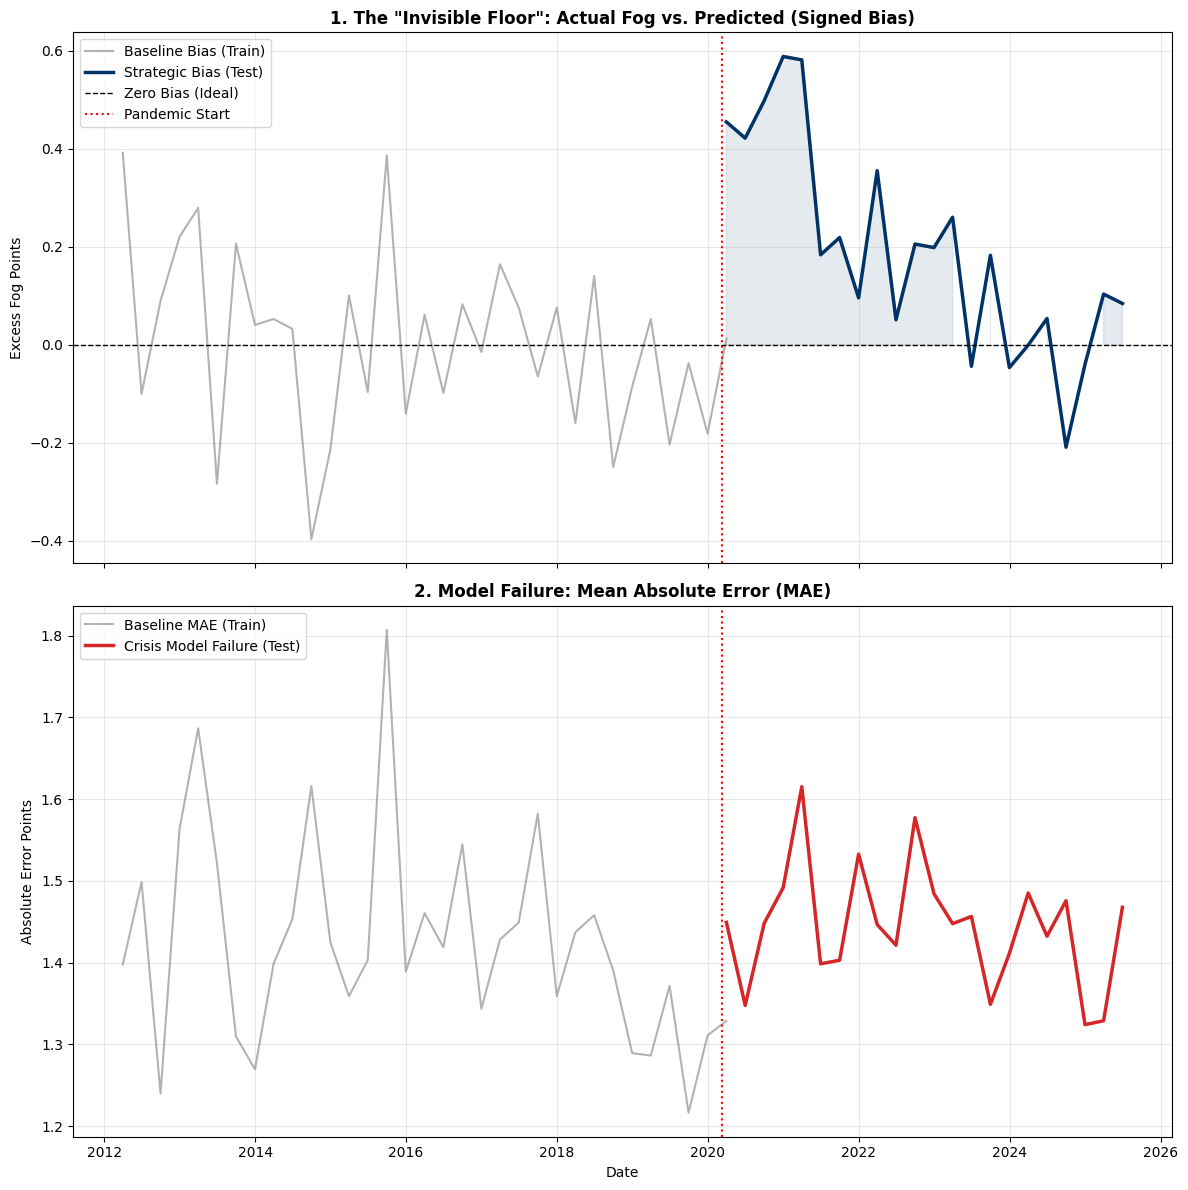


--- Feature Importance (Hybrid Market + Scaled Text) ---
speaker_finbert_negative          0.176968
first_person_singular_per_min     0.153768
singular_pronoun_ratio            0.093539
constraining_per_min              0.059165
numerosity_ratio                  0.057659
pitch_std                         0.052118
positive_per_min                  0.044054
numerosity_numbers_per_min        0.039800
numerosity_total_words_per_min    0.031657
jitter                            0.031441
first_person_plural_per_min       0.028894
video_duration_sec                0.024754
recent_vol_30d                    0.022224
prev_q_volatility                 0.021949
prev_q_return                     0.021490
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Setup Data
# ---------------------------------------------------------
# Load the dataset (containing the new Hybrid Daily Market Data)
df = pd.read_csv('ultimate_fog_dataset.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'])
df = df.set_index('publish_date').sort_index()

# 2. FEATURE ENGINEERING: Create "Rate Variables" (Per Minute)
# ---------------------------------------------------------
# Even if df_norm exists conceptually, we ensure the columns are created here.

# A. Clean Duration (Convert to Minutes)
def clean_duration_to_minutes(val):
    try:
        val = str(val).strip()
        parts = val.split(':')
        if len(parts) == 2: # "MM:SS"
            seconds = int(parts[0]) * 60 + int(parts[1])
        elif len(parts) == 3: # "HH:MM:SS"
            seconds = int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        else:
            seconds = float(val)
        return seconds / 60.0 if seconds > 0 else np.nan
    except:
        return np.nan

df['duration_minutes'] = df['video_duration'].apply(clean_duration_to_minutes)
df['video_duration_sec'] = df['duration_minutes'] * 60

# B. Scale Count Columns -> Rate Columns
count_cols_to_scale = [
    'positive_word_count_executive',
    'negative_word_count_executive',
    'strong_modal_word_count_executive',
    'weak_modal_word_count_executive',
    'uncertainty_word_count_executive',
    'constraining_word_count_executive',
    'litigious_word_count_executive',
    'numerosity_numbers',
    'numerosity_total_words',
    'first_person_singular',
    'first_person_plural'
]

scaled_features_list = []

print("--- Creating Scaled Features ---")
for col in count_cols_to_scale:
    if col in df.columns:
        # Create new name: e.g., 'uncertainty_per_min'
        base_name = col.replace('_word_count_executive', '').replace('_executive', '')
        new_col_name = base_name + '_per_min'

        # Calculate Rate
        df[new_col_name] = df[col] / df['duration_minutes']

        scaled_features_list.append(new_col_name)
        # print(f"Created: {new_col_name}")

# 3. Define Final Feature List (UPDATED)
# ---------------------------------------------------------
features = [
    # --- The New Hybrid Market Controls (Daily/Rolling) ---
    'recent_ret_7d',         # Immediate Sentiment (Last Week)
    'recent_ret_30d',        # Monthly Trend
    'recent_vol_30d',        # Recent Panic/Uncertainty
    'recent_abnormal_vol',   # Abnormal Attention (Volume Spike)
    'prev_q_return',         # Fundamental Baseline (Last Quarter)
    'prev_q_volatility',     # Fundamental Risk (Last Quarter)
    # 'price_close',         # Optional: Raw price level (usually excluded in favor of returns)

    # --- The Scaled Text Features (The "Soft" Signals) ---
    *scaled_features_list,   # Unpacks the list of '_per_min' variables

    # --- Ratios & Audio ---
    'numerosity_ratio',
    'singular_pronoun_ratio',
    'pitch_std',
    'jitter',
    'video_duration_sec',

    # --- Sentiment & Meta ---
    'speaker_finbert_negative',
    'is_CEO',
    'is_CFO'
]

# Ensure boolean columns are integers
for col in ['is_CEO', 'is_CFO']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# HANDLE MISSING VALUES
# Drop rows where any of the features (including the new market ones) are NaN
df_model = df.dropna(subset=features + ['fog_index'])

# 4. The Counterfactual Split
# ---------------------------------------------------------
pandemic_start = pd.Timestamp('2020-03-11')

X = df_model[features]
y = df_model['fog_index']

X_train = X[X.index < pandemic_start]
y_train = y[y.index < pandemic_start]

X_test = X[X.index >= pandemic_start]
y_test = y[y.index >= pandemic_start]

print(f"\nTraining on {len(X_train)} pre-pandemic interviews.")
print(f"Testing on {len(X_test)} post-pandemic interviews.")

# 5. Train the Model (REGULARIZED VERSION)
# ---------------------------------------------------------
print("Training Regularized Random Forest...")

# We introduce constraints to prevent the model from 'memorizing' the training data
rf = RandomForestRegressor(
    n_estimators=200,       # More trees = smoother predictions (reduces variance)

    # CONSTRAINT 1: The "Handbrake" (Most Important)
    # Forces the model to form rules based on at least 20 interviews, not 1.
    # This prevents it from isolating outliers or unique video lengths.
    min_samples_leaf=20,

    # CONSTRAINT 2: Depth Limit
    # Prevents the model from learning highly complex, non-linear patterns
    # that are likely just noise in the training set.
    max_depth=10,

    # CONSTRAINT 3: Feature Decorrelation
    # Forces the model to use different features for different splits.
    # 'sqrt' means it sees only ~6 features at each split, preventing
    # one dominant feature (like video_duration) from overpowering the tree.
    max_features='sqrt',

    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# 6. Predict & Calculate Error
# ---------------------------------------------------------
# A. Baseline Error (Train Set)
y_pred_train = rf.predict(X_train)
train_residuals = y_train - y_pred_train
train_abs_error = np.abs(train_residuals)

# B. Crisis Error (Test Set)
y_pred_test = rf.predict(X_test)
residuals = y_test - y_pred_test
test_abs_error = np.abs(residuals)

# 7. Visualization: Train vs. Test Error
# ---------------------------------------------------------
q_train_resid = train_residuals.resample('Q').mean()
q_test_resid = residuals.resample('Q').mean()

q_train_abs = train_abs_error.resample('Q').mean()
q_test_abs = test_abs_error.resample('Q').mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# --- Subplot 1: Signed Residuals (Bias) ---
ax1.plot(q_train_resid.index, q_train_resid.values, color='gray', alpha=0.6, linestyle='-', label='Baseline Bias (Train)')
ax1.plot(q_test_resid.index, q_test_resid.values, color='#003366', linewidth=2.5, label='Strategic Bias (Test)')

ax1.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Bias (Ideal)')
ax1.axvline(pandemic_start, color='red', linestyle=':', label='Pandemic Start')
ax1.fill_between(q_test_resid.index, 0, q_test_resid.values, where=(q_test_resid.values > 0), color='#003366', alpha=0.1)

ax1.set_title('1. The "Invisible Floor": Actual Fog vs. Predicted (Signed Bias)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Excess Fog Points')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Absolute Error (MAE) ---
ax2.plot(q_train_abs.index, q_train_abs.values, color='gray', alpha=0.6, linestyle='-', label='Baseline MAE (Train)')
ax2.plot(q_test_abs.index, q_test_abs.values, color='#d62728', linewidth=2.5, label='Crisis Model Failure (Test)')

ax2.axvline(pandemic_start, color='red', linestyle=':')
ax2.set_title('2. Model Failure: Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Absolute Error Points')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save Plot
plt.savefig('random_forest_counterfactual_hybrid.png', dpi=300)
print("Plot saved to 'random_forest_counterfactual_hybrid.png'")
plt.show()

# 8. Feature Importance
# ---------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance (Hybrid Market + Scaled Text) ---")
print(importances.head(15))

We observe that NLP features play the most role in determining the prediction, and interestingly, the market variables rather have less influence among the features.

Also, for the error plots, we observe something interesting. The complexity at the start of the pandemic is mostly *underestimated* by the model even though the Mean Absolute Error plot shows the absolute error preserves its level, further supporting the underestimation of the complexity. The high error we observe in the beginning of the pandemic suggests that the dataset and/or the modeling is missing the underlying factors of this spike. This analysis *could not* explain the mechanisms of this complexity spike with the sources at hand.

It is also the case that there is a particular error margin, suggesting that the model is missing a particular margin of the underlying mechanisms of the complexity. This could also be because of the dataset size.


Training on 8493 pre-pandemic interviews.
Testing on 11904 post-pandemic interviews.
Training Regularized Random Forest...


/tmp/ipykernel_17087/766441738.py:154: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_train_resid = train_residuals.resample('Q').mean()
/tmp/ipykernel_17087/766441738.py:155: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_test_resid = residuals.resample('Q').mean()
/tmp/ipykernel_17087/766441738.py:157: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_train_abs = train_abs_error.resample('Q').mean()
/tmp/ipykernel_17087/766441738.py:158: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  q_test_abs = test_abs_error.resample('Q').mean()


Plot saved to 'random_forest_counterfactual_hybrid.png'


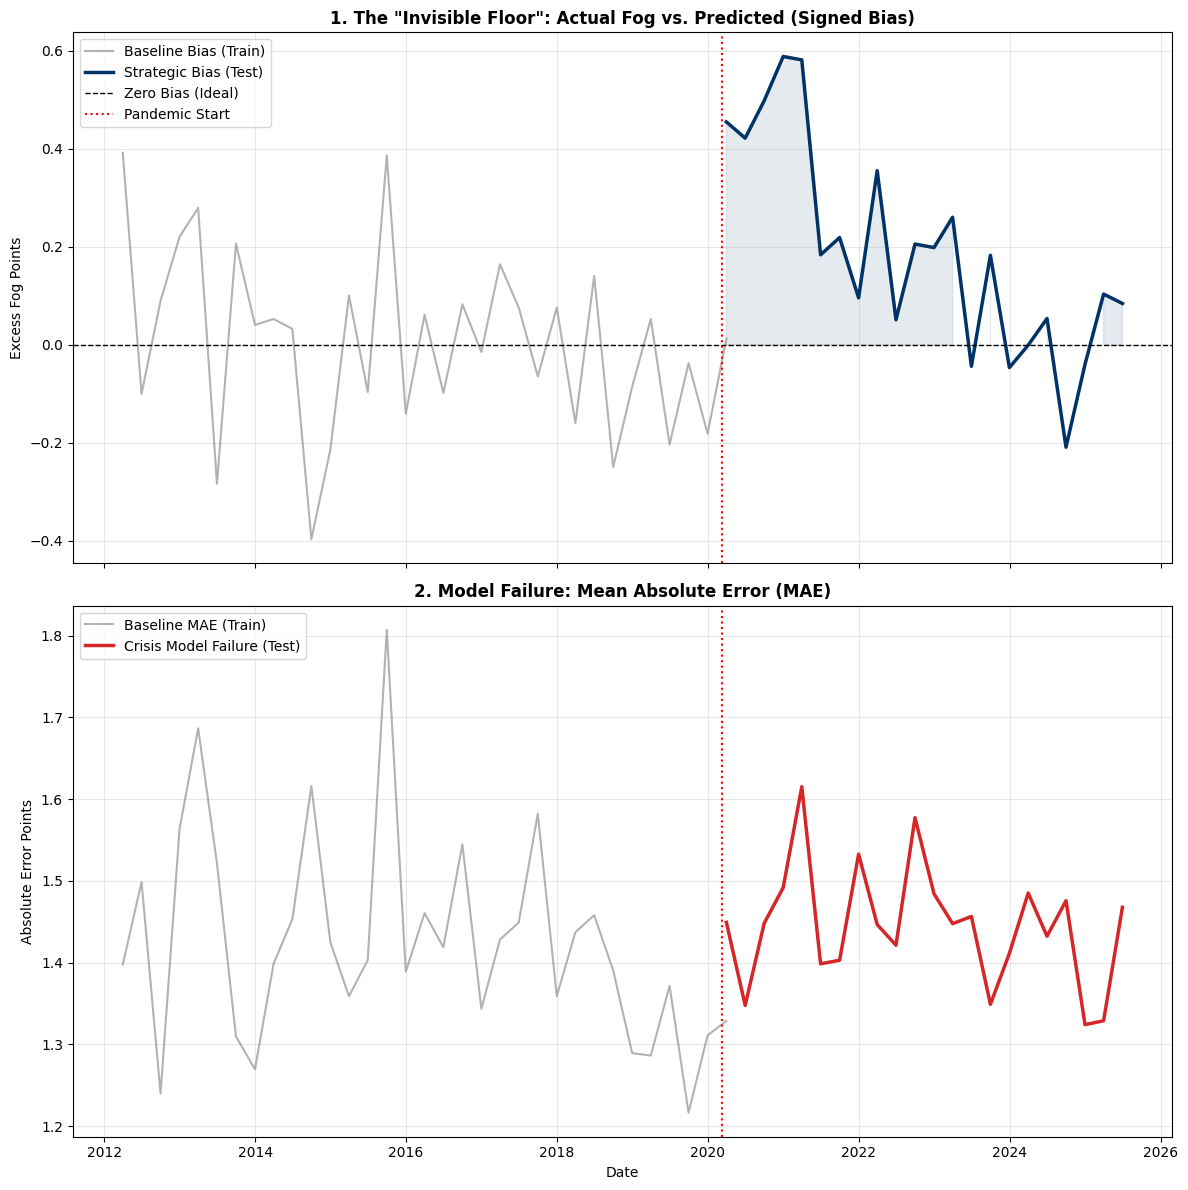


--- Feature Importance (Hybrid Market + Scaled Text) ---
speaker_finbert_negative          0.176968
first_person_singular_per_min     0.153768
singular_pronoun_ratio            0.093539
constraining_per_min              0.059165
numerosity_ratio                  0.057659
pitch_std                         0.052118
positive_per_min                  0.044054
numerosity_numbers_per_min        0.039800
numerosity_total_words_per_min    0.031657
jitter                            0.031441
first_person_plural_per_min       0.028894
video_duration                    0.024754
recent_vol_30d                    0.022224
prev_q_volatility                 0.021949
prev_q_return                     0.021490
dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# 1. Setup Data
# ---------------------------------------------------------
# We assume df_norm exists and already contains scaled variables (e.g., 'uncertainty_per_min')
try:
    df = df_norm.copy()
except NameError:
    raise NameError("df_norm not found in memory. Please run the scaling script first.")

# Ensure index is datetime and sorted
df['publish_date'] = pd.to_datetime(df['publish_date'])
df = df.set_index('publish_date').sort_index()

# 2. Define Feature List
# ---------------------------------------------------------
# Since we skipped the dynamic scaling loop, we list the expected scaled columns manually.
scaled_features_list = [
    'positive_per_min',
    'negative_per_min',
    'strong_modal_per_min',
    'weak_modal_per_min',
    'uncertainty_per_min',
    'constraining_per_min',
    'litigious_per_min',
    'numerosity_numbers_per_min',
    'numerosity_total_words_per_min',
    'first_person_singular_per_min',
    'first_person_plural_per_min'
]

features = [
    # --- The Hybrid Market Controls (Daily/Rolling) ---
    'recent_ret_7d',         # Immediate Sentiment (Last Week)
    'recent_ret_30d',        # Monthly Trend
    'recent_vol_30d',        # Recent Panic/Uncertainty
    'recent_abnormal_vol',   # Abnormal Attention (Volume Spike)
    'prev_q_return',         # Fundamental Baseline (Last Quarter)
    'prev_q_volatility',     # Fundamental Risk (Last Quarter)

    # --- The Scaled Text Features (The "Soft" Signals) ---
    *scaled_features_list,   # Unpacks the list above

    # --- Ratios & Audio ---
    'numerosity_ratio',
    'singular_pronoun_ratio',
    'pitch_std',
    'jitter',
    'video_duration',

    # --- Sentiment & Meta ---
    'speaker_finbert_negative',
    'is_CEO',
    'is_CFO'
]

# Ensure boolean columns are integers
for col in ['is_CEO', 'is_CFO']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# --- Convert video_duration to numeric (total seconds) ---
def duration_to_seconds(time_str):
    if pd.isna(time_str):
        return np.nan
    if isinstance(time_str, (int, float)):
        return time_str # Already a number

    parts = str(time_str).split(':')
    try:
        if len(parts) == 2: # Format is MM:SS
            return int(parts[0]) * 60 + int(parts[1])
        elif len(parts) == 3: # Format is HH:MM:SS
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
    except ValueError:
        return np.nan # Catch any weird formatting

    return np.nan

# Apply the conversion to the column
if 'video_duration' in df.columns:
    df['video_duration'] = df['video_duration'].apply(duration_to_seconds)

# --- Ensure boolean columns are integers ---
# (Keep your existing boolean conversion here)
for col in ['is_CEO', 'is_CFO']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

# HANDLE MISSING VALUES
# Drop rows where any of the features are NaN
df_model = df.dropna(subset=features + ['fog_index'])

# 3. The Counterfactual Split
# ---------------------------------------------------------
pandemic_start = pd.Timestamp('2020-03-11')

X = df_model[features]
y = df_model['fog_index']

X_train = X[X.index < pandemic_start]
y_train = y[y.index < pandemic_start]

X_test = X[X.index >= pandemic_start]
y_test = y[y.index >= pandemic_start]

print(f"\nTraining on {len(X_train)} pre-pandemic interviews.")
print(f"Testing on {len(X_test)} post-pandemic interviews.")

# 4. Train the Model (REGULARIZED VERSION)
# ---------------------------------------------------------
print("Training Regularized Random Forest...")

# We introduce constraints to prevent the model from 'memorizing' the training data
rf = RandomForestRegressor(
    n_estimators=200,       # More trees = smoother predictions (reduces variance)

    # CONSTRAINT 1: The "Handbrake" (Most Important)
    # Forces the model to form rules based on at least 20 interviews, not 1.
    min_samples_leaf=20,

    # CONSTRAINT 2: Depth Limit
    # Prevents the model from learning highly complex, non-linear patterns
    max_depth=10,

    # CONSTRAINT 3: Feature Decorrelation
    # Forces the model to use different features for different splits.
    max_features='sqrt',

    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# 5. Predict & Calculate Error
# ---------------------------------------------------------
# A. Baseline Error (Train Set)
y_pred_train = rf.predict(X_train)
train_residuals = y_train - y_pred_train
train_abs_error = np.abs(train_residuals)

# B. Crisis Error (Test Set)
y_pred_test = rf.predict(X_test)
residuals = y_test - y_pred_test
test_abs_error = np.abs(residuals)

# 6. Visualization: Train vs. Test Error
# ---------------------------------------------------------
q_train_resid = train_residuals.resample('Q').mean()
q_test_resid = residuals.resample('Q').mean()

q_train_abs = train_abs_error.resample('Q').mean()
q_test_abs = test_abs_error.resample('Q').mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# --- Subplot 1: Signed Residuals (Bias) ---
ax1.plot(q_train_resid.index, q_train_resid.values, color='gray', alpha=0.6, linestyle='-', label='Baseline Bias (Train)')
ax1.plot(q_test_resid.index, q_test_resid.values, color='#003366', linewidth=2.5, label='Strategic Bias (Test)')

ax1.axhline(0, color='black', linestyle='--', linewidth=1, label='Zero Bias (Ideal)')
ax1.axvline(pandemic_start, color='red', linestyle=':', label='Pandemic Start')
ax1.fill_between(q_test_resid.index, 0, q_test_resid.values, where=(q_test_resid.values > 0), color='#003366', alpha=0.1)

ax1.set_title('1. The "Invisible Floor": Actual Fog vs. Predicted (Signed Bias)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Excess Fog Points')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Absolute Error (MAE) ---
ax2.plot(q_train_abs.index, q_train_abs.values, color='gray', alpha=0.6, linestyle='-', label='Baseline MAE (Train)')
ax2.plot(q_test_abs.index, q_test_abs.values, color='#d62728', linewidth=2.5, label='Crisis Model Failure (Test)')

ax2.axvline(pandemic_start, color='red', linestyle=':')
ax2.set_title('2. Model Failure: Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Absolute Error Points')
ax2.set_xlabel('Date')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save Plot
plt.savefig('random_forest_counterfactual_hybrid.png', dpi=300)
print("Plot saved to 'random_forest_counterfactual_hybrid.png'")
plt.show()

# 7. Feature Importance
# ---------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\n--- Feature Importance (Hybrid Market + Scaled Text) ---")
print(importances.head(15))